Оценка качества моделей Google Cluster

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df_5m       = pd.read_parquet('FE_google/features_result/predictions_5m_models.parquet')
df_24h      = pd.read_parquet('FE_google/features_result/predictions_24h_models.parquet')
df_lifetime = pd.read_parquet('FE_google/features_result/predictions_lifetime_models.parquet')
df_lstm     = pd.read_parquet('FE_google/lstm_data/lstm_test_predictions_full.parquet')
df_arima_3k = pd.read_parquet('FE_google/features_result/predictions_arima_test_sample.parquet')
df_arima_10k= pd.read_parquet('FE_google/features_result/predictions_arima_test_sample_10k.parquet')

print("=== predictions_5m_models ===")
print(df_5m.columns.tolist())
print(df_5m.head(3))

print("\n=== predictions_24h_models ===")
print(df_24h.columns.tolist())
print(df_24h.head(3))

print("\n=== predictions_lifetime_models ===")
print(df_lifetime.columns.tolist())
print(df_lifetime.head(3))

print("\n=== lstm_test_predictions_full ===")
print(df_lstm.columns.tolist())
print(df_lstm.head(3))

print("\n=== predictions_arima_test_sample (3k) ===")
print(df_arima_3k.columns.tolist())
print(df_arima_3k.head(3))

print("\n=== predictions_arima_test_sample_10k ===")
print(df_arima_10k.columns.tolist())
print(df_arima_10k.head(3))

=== predictions_5m_models ===
['vm_id', 'trace_minute', 'sample_row_id', 'target', 'y_true', 'pred_linear_regression', 'pred_random_forest_default', 'pred_catboost_default', 'pred_random_forest_tuned', 'pred_catboost_tuned', 'pred_ensemble']
               vm_id  trace_minute  sample_row_id             target  \
0  a_70798710256_184       23695.0              2  target_avg_cpu_5m   
1  a_70798710256_184       16765.0          23515  target_avg_cpu_5m   
2  a_70798710256_184       19595.0          28673  target_avg_cpu_5m   

     y_true  pred_linear_regression  pred_random_forest_default  \
0  0.057098                0.088752                    0.083024   
1  0.190704                0.236364                    0.174570   
2  0.040201                0.039530                    0.038974   

   pred_catboost_default  pred_random_forest_tuned  pred_catboost_tuned  \
0               0.085352                  0.078394             0.079996   
1               0.157122                  0.175813

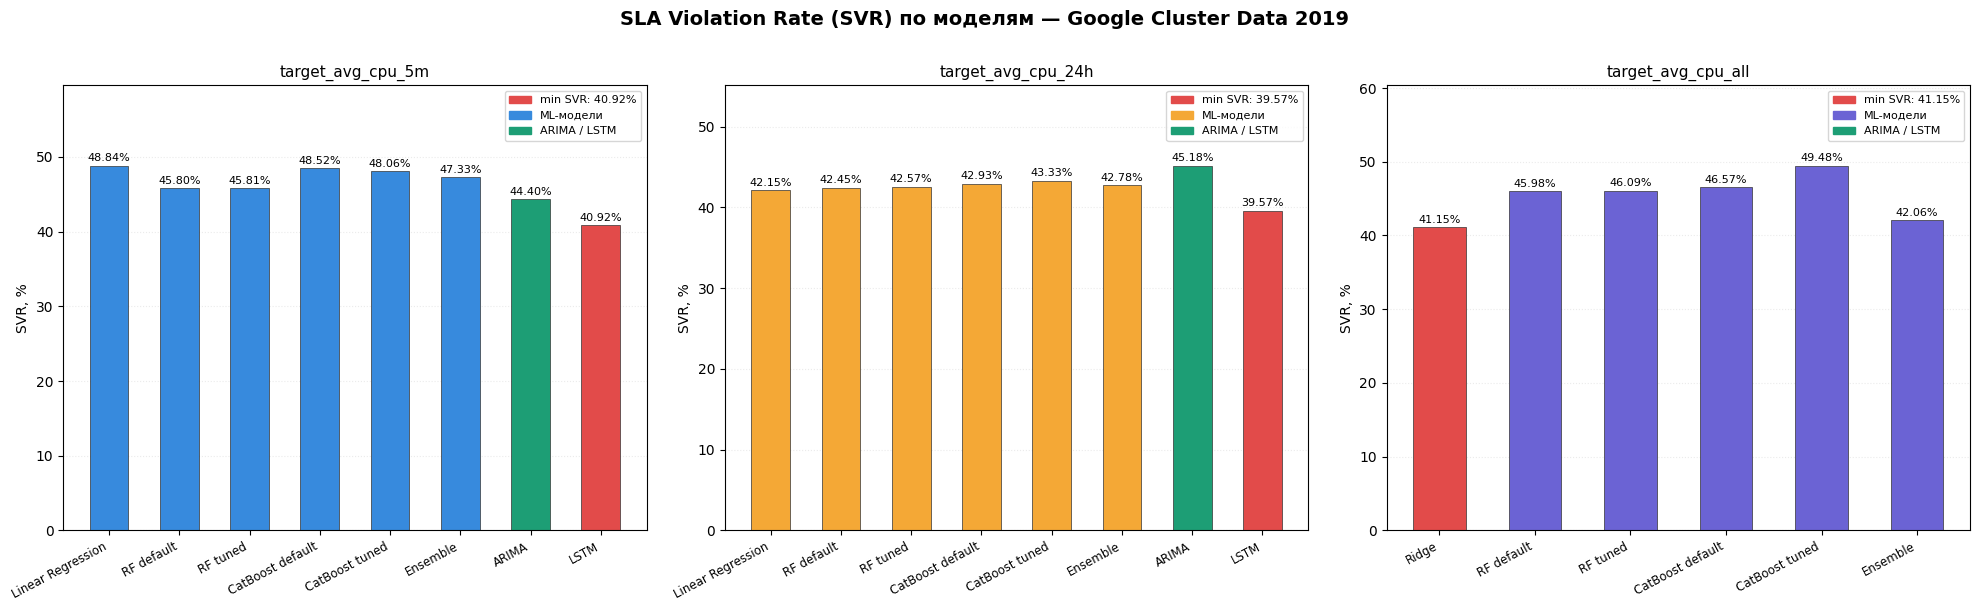

График сохранён: google_svr_bar.png


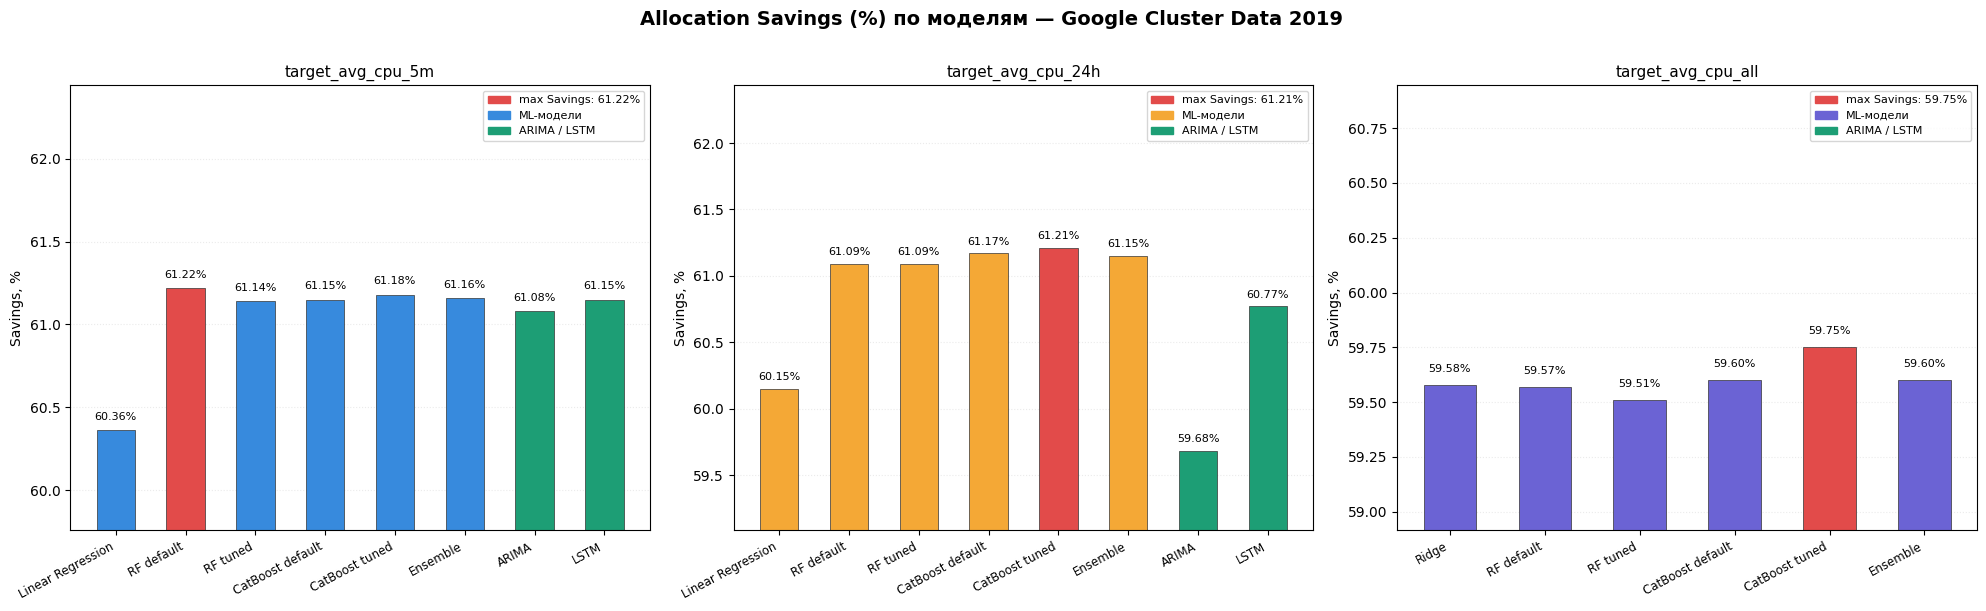

График сохранён: google_savings_bar.png


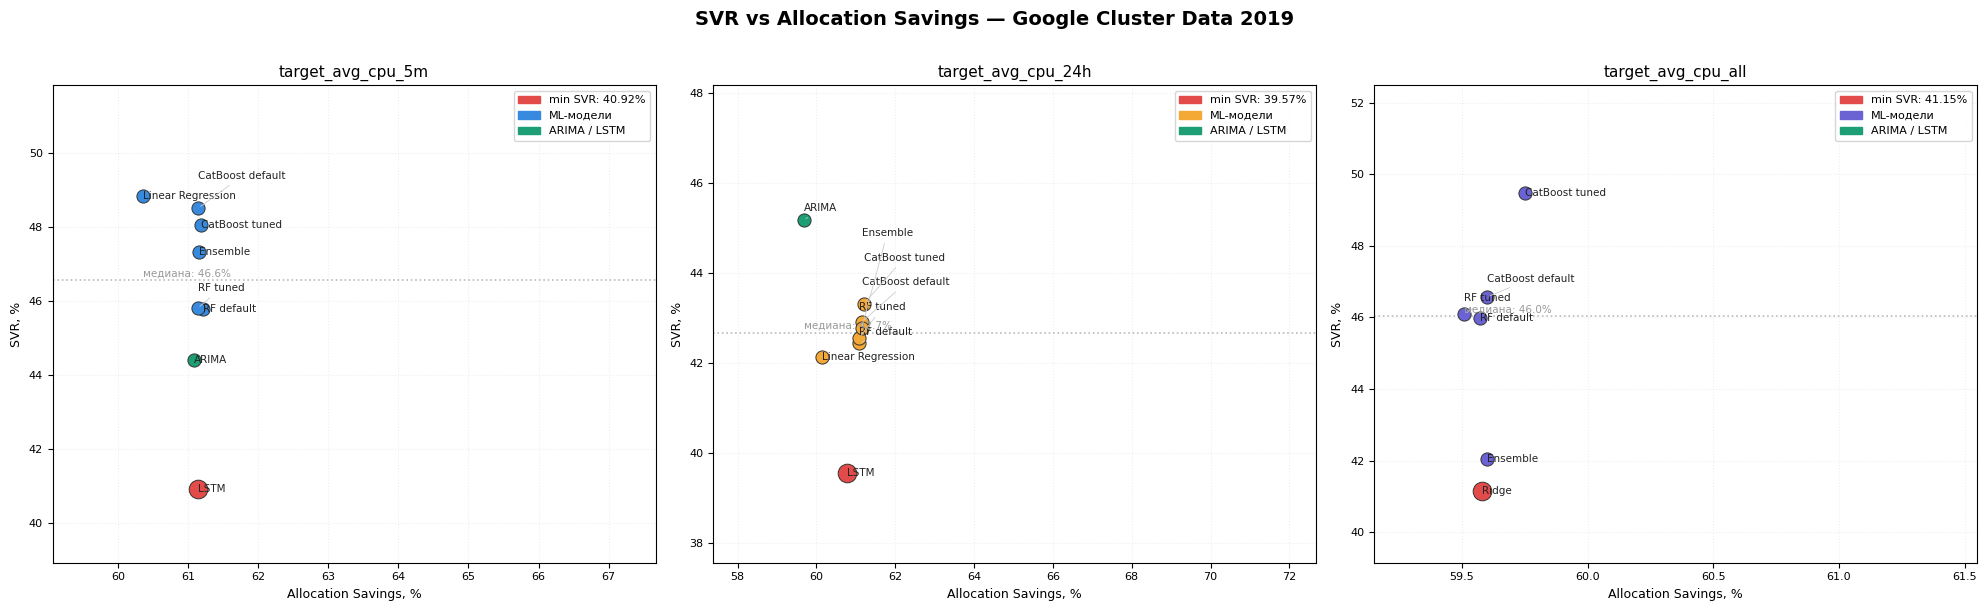

График сохранён: google_svr_vs_savings.png


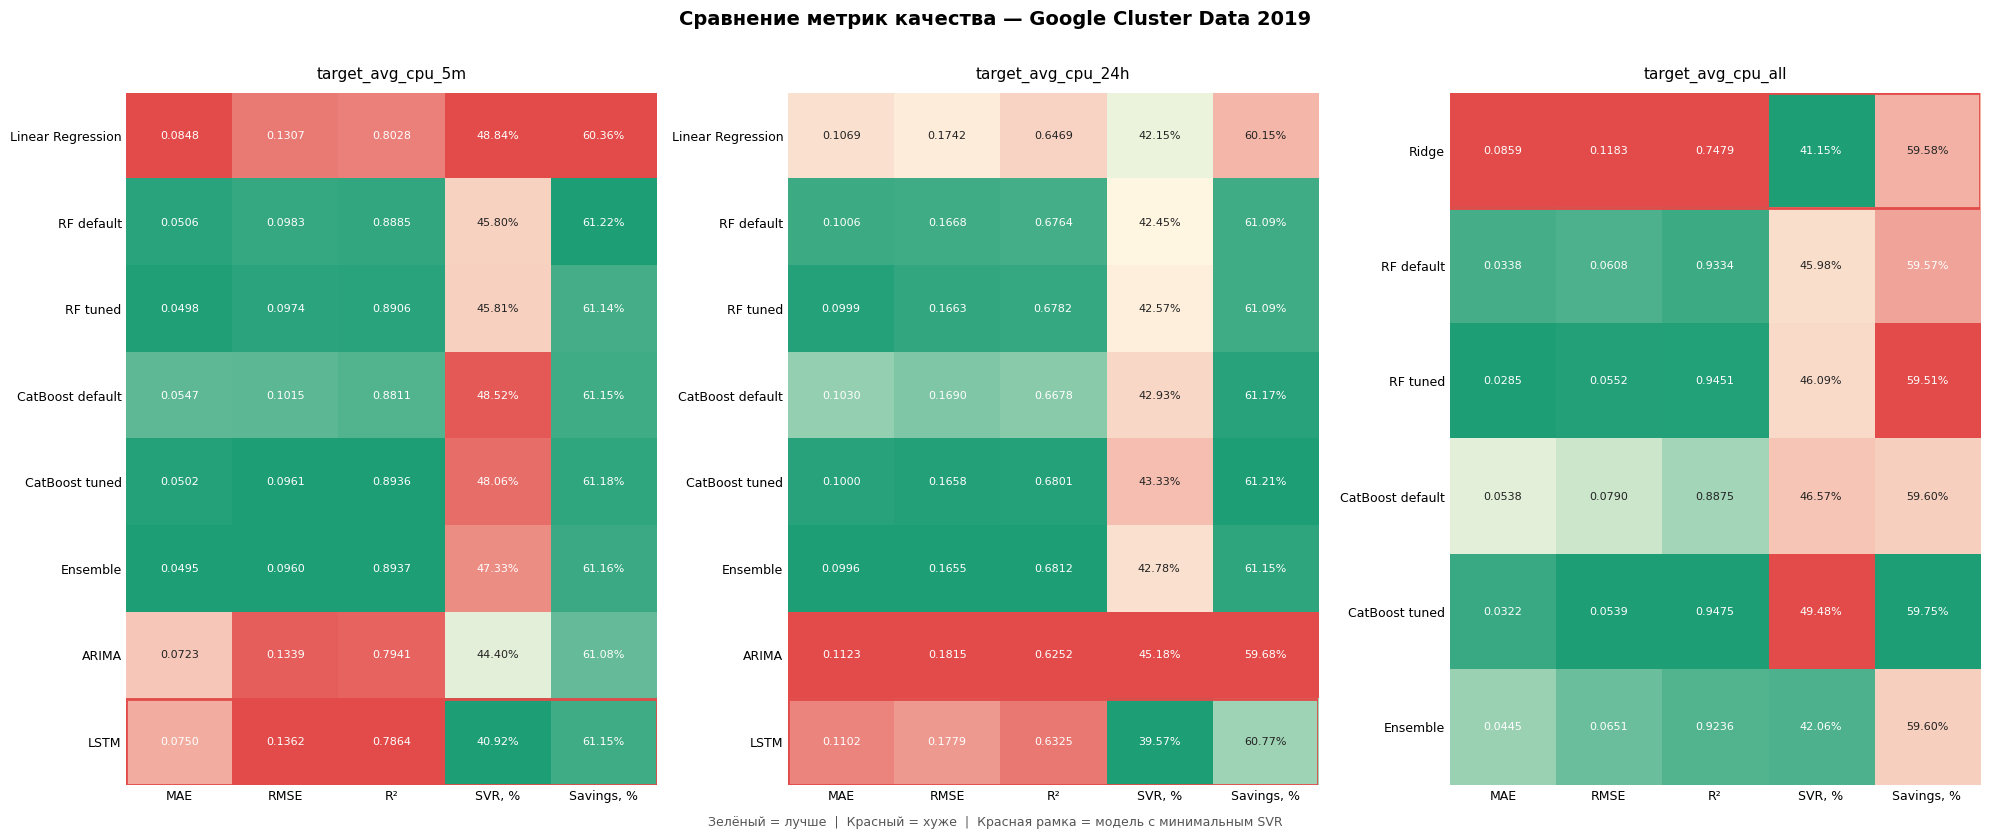

График сохранён: google_heatmap_metrics.png


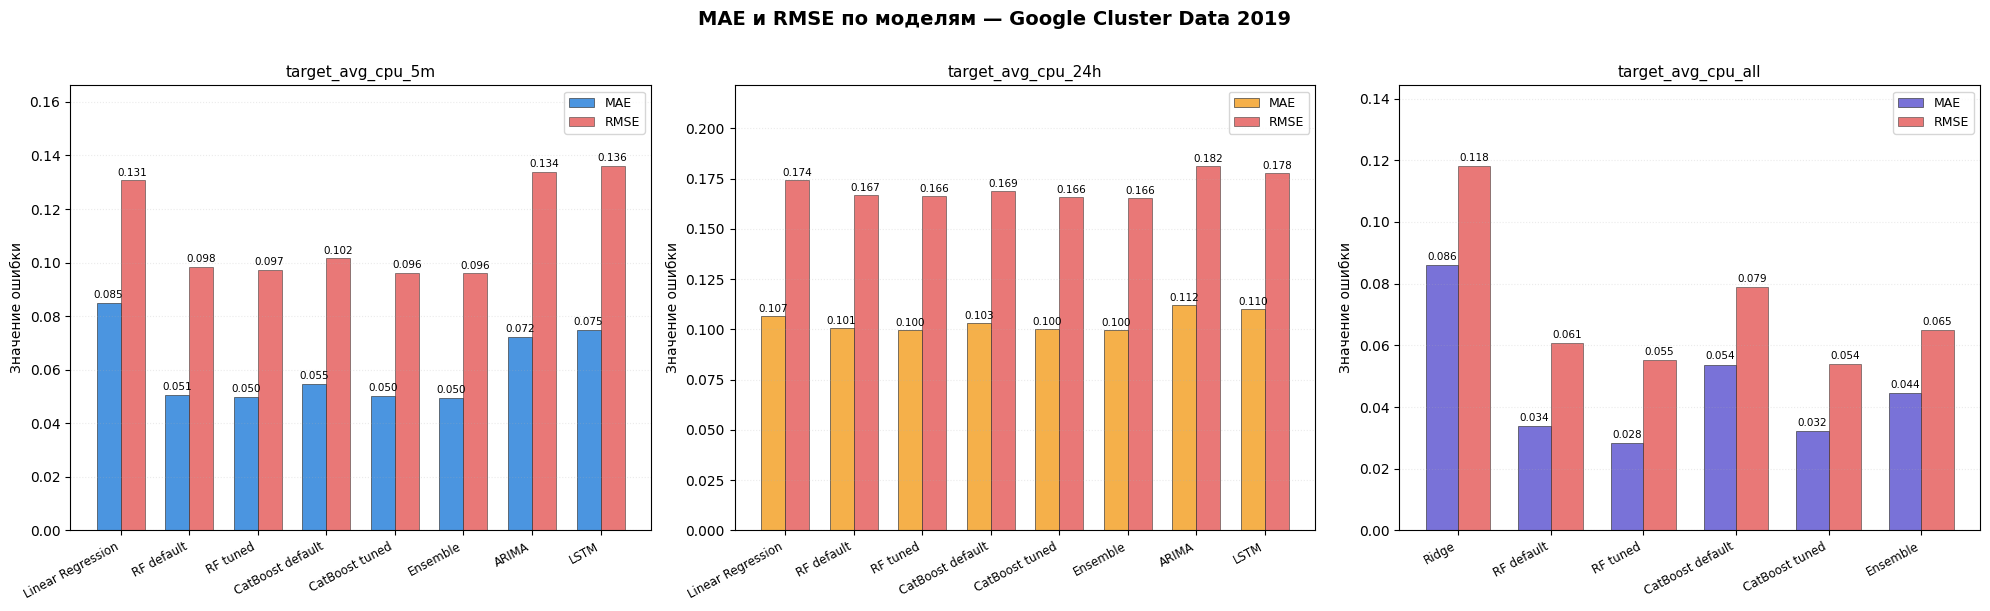

График сохранён: google_mae_rmse.png


  СВОДНАЯ ТАБЛИЦА — GOOGLE CLUSTER DATA 2019
  Таргет                 Модель                     MAE    RMSE      R²   SVR,%   Sav,%
--------------------------------------------------------------------------------
  target_avg_cpu_5m      Linear Regression       0.0848  0.1307  0.8028  48.84%  60.36%
  target_avg_cpu_5m      RF default              0.0506  0.0983  0.8885  45.80%  61.22%
  target_avg_cpu_5m      RF tuned                0.0498  0.0974  0.8906  45.81%  61.14%
  target_avg_cpu_5m      CatBoost default        0.0547  0.1015  0.8811  48.52%  61.15%
  target_avg_cpu_5m      CatBoost tuned          0.0502  0.0961  0.8936  48.06%  61.18%
  target_avg_cpu_5m      Ensemble                0.0495  0.0960  0.8937  47.33%  61.16%
  target_avg_cpu_5m      ARIMA                   0.0723  0.1339  0.7941  44.40%  61.08%
  target_avg_cpu_5m      LSTM                    0.0750  0.1362  0.7864  40.92%  61.15% ◄
-----------------------------------------

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

data = {
    'target_5min': {
        'Linear Regression':  {'mae': 0.084847, 'rmse': 0.130741, 'r2': 0.802836, 'svr': 48.84, 'savings': 60.36},
        'RF default':         {'mae': 0.050601, 'rmse': 0.098325, 'r2': 0.888486, 'svr': 45.80, 'savings': 61.22},
        'RF tuned':           {'mae': 0.049789, 'rmse': 0.097393, 'r2': 0.890589, 'svr': 45.81, 'savings': 61.14},
        'CatBoost default':   {'mae': 0.054745, 'rmse': 0.101541, 'r2': 0.881071, 'svr': 48.52, 'savings': 61.15},
        'CatBoost tuned':     {'mae': 0.050230, 'rmse': 0.096057, 'r2': 0.893570, 'svr': 48.06, 'savings': 61.18},
        'Ensemble':           {'mae': 0.049508, 'rmse': 0.096014, 'r2': 0.893666, 'svr': 47.33, 'savings': 61.16},
        'ARIMA':              {'mae': 0.072309, 'rmse': 0.133920, 'r2': 0.794129, 'svr': 44.40, 'savings': 61.08},
        'LSTM':               {'mae': 0.075007, 'rmse': 0.136220, 'r2': 0.786402, 'svr': 40.92, 'savings': 61.15},
    },
    'target_24h': {
        'Linear Regression':  {'mae': 0.106885, 'rmse': 0.174208, 'r2': 0.646884, 'svr': 42.15, 'savings': 60.15},
        'RF default':         {'mae': 0.100584, 'rmse': 0.166777, 'r2': 0.676370, 'svr': 42.45, 'savings': 61.09},
        'RF tuned':           {'mae': 0.099904, 'rmse': 0.166317, 'r2': 0.678150, 'svr': 42.57, 'savings': 61.09},
        'CatBoost default':   {'mae': 0.103024, 'rmse': 0.168966, 'r2': 0.667819, 'svr': 42.93, 'savings': 61.17},
        'CatBoost tuned':     {'mae': 0.099975, 'rmse': 0.165810, 'r2': 0.680109, 'svr': 43.33, 'savings': 61.21},
        'Ensemble':           {'mae': 0.099649, 'rmse': 0.165517, 'r2': 0.681238, 'svr': 42.78, 'savings': 61.15},
        'ARIMA':              {'mae': 0.112284, 'rmse': 0.181533, 'r2': 0.625177, 'svr': 45.18, 'savings': 59.68},
        'LSTM':               {'mae': 0.110182, 'rmse': 0.177916, 'r2': 0.632498, 'svr': 39.57, 'savings': 60.77},
    },
    'target_lifetime': {
        'Ridge':              {'mae': 0.085924, 'rmse': 0.118276, 'r2': 0.747851, 'svr': 41.15, 'savings': 59.58},
        'RF default':         {'mae': 0.033754, 'rmse': 0.060765, 'r2': 0.933446, 'svr': 45.98, 'savings': 59.57},
        'RF tuned':           {'mae': 0.028451, 'rmse': 0.055190, 'r2': 0.945098, 'svr': 46.09, 'savings': 59.51},
        'CatBoost default':   {'mae': 0.053762, 'rmse': 0.078987, 'r2': 0.887544, 'svr': 46.57, 'savings': 59.60},
        'CatBoost tuned':     {'mae': 0.032181, 'rmse': 0.053949, 'r2': 0.947539, 'svr': 49.48, 'savings': 59.75},
        'Ensemble':           {'mae': 0.044458, 'rmse': 0.065087, 'r2': 0.923642, 'svr': 42.06, 'savings': 59.60},
    },
}

TASK_LABELS = {
    'target_5min':     'target_avg_cpu_5m',
    'target_24h':      'target_avg_cpu_24h',
    'target_lifetime': 'target_avg_cpu_all',
}
TASK_COLORS = {
    'target_5min':     '#378ADD',
    'target_24h':      '#F4A836',
    'target_lifetime': '#6B63D4',
}

# модели ARIMA/LSTM выделяем отдельным цветом
TS_MODELS = {'ARIMA', 'LSTM'}


# ==============================================================
# ГРАФИК 1: SVR BAR CHART
# ==============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('SLA Violation Rate (SVR) по моделям — Google Cluster Data 2019',
             fontsize=14, fontweight='bold', y=1.01)

for ax, (task, label) in zip(axes, TASK_LABELS.items()):
    models = list(data[task].keys())
    values = [data[task][m]['svr'] for m in models]
    best   = min(values)
    colors = []
    for m, v in zip(models, values):
        if v == best:
            colors.append('#E24B4A')
        elif m in TS_MODELS:
            colors.append('#1D9E75')
        else:
            colors.append(TASK_COLORS[task])

    x    = np.arange(len(models))
    bars = ax.bar(x, values, color=colors, edgecolor='#333',
                  linewidth=0.5, width=0.55, zorder=2)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{val:.2f}%', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=28, ha='right', fontsize=8.5)
    ax.set_ylabel('SVR, %', fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='medium')
    ax.set_ylim(0, max(values) * 1.22)
    ax.grid(axis='y', alpha=0.25, linestyle=':')

    best_patch = mpatches.Patch(color='#E24B4A',    label=f'min SVR: {best:.2f}%')
    rest_patch = mpatches.Patch(color=TASK_COLORS[task], label='ML-модели')
    ts_patch   = mpatches.Patch(color='#1D9E75',    label='ARIMA / LSTM')
    ax.legend(handles=[best_patch, rest_patch, ts_patch], fontsize=8)

plt.tight_layout()
plt.savefig('google_svr_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("График сохранён: google_svr_bar.png")


# ==============================================================
# ГРАФИК 2: ALLOCATION SAVINGS BAR CHART
# ==============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Allocation Savings (%) по моделям — Google Cluster Data 2019',
             fontsize=14, fontweight='bold', y=1.01)

for ax, (task, label) in zip(axes, TASK_LABELS.items()):
    models = list(data[task].keys())
    values = [data[task][m]['savings'] for m in models]
    best   = max(values)
    colors = []
    for m, v in zip(models, values):
        if v == best:
            colors.append('#E24B4A')
        elif m in TS_MODELS:
            colors.append('#1D9E75')
        else:
            colors.append(TASK_COLORS[task])

    x    = np.arange(len(models))
    bars = ax.bar(x, values, color=colors, edgecolor='#333',
                  linewidth=0.5, width=0.55, zorder=2)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.05,
                f'{val:.2f}%', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=28, ha='right', fontsize=8.5)
    ax.set_ylabel('Savings, %', fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='medium')
    ax.set_ylim(min(values) * 0.99, max(values) * 1.02)
    ax.grid(axis='y', alpha=0.25, linestyle=':')

    best_patch = mpatches.Patch(color='#E24B4A',         label=f'max Savings: {best:.2f}%')
    rest_patch = mpatches.Patch(color=TASK_COLORS[task], label='ML-модели')
    ts_patch   = mpatches.Patch(color='#1D9E75',         label='ARIMA / LSTM')
    ax.legend(handles=[best_patch, rest_patch, ts_patch], fontsize=8)

plt.tight_layout()
plt.savefig('google_savings_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("График сохранён: google_savings_bar.png")


# ==============================================================
# ГРАФИК 3: SVR vs SAVINGS SCATTER
# ==============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('SVR vs Allocation Savings — Google Cluster Data 2019',
             fontsize=14, fontweight='bold', y=1.01)

for ax, (task, label) in zip(axes, TASK_LABELS.items()):
    models = list(data[task].keys())
    svrs   = [data[task][m]['svr']     for m in models]
    savs   = [data[task][m]['savings'] for m in models]
    best   = min(svrs)

    for m, sv, sa in zip(models, svrs, savs):
        is_best = sv == best
        if is_best:
            color = '#E24B4A'
        elif m in TS_MODELS:
            color = '#1D9E75'
        else:
            color = TASK_COLORS[task]
        size = 180 if is_best else 90
        ax.scatter(sa, sv, color=color, s=size,
                   edgecolors='#333', linewidths=0.7, zorder=3)

    # подписи с разносом по Y
    used_y = []
    for m, sv, sa in zip(models, svrs, savs):
        y_text = sv
        for yu in used_y:
            if abs(y_text - yu) < 0.5:
                y_text = yu + 0.55
        used_y.append(y_text)
        ax.annotate(m, xy=(sa, sv), xytext=(sa, y_text),
                    fontsize=7.5, color='#222', ha='left', va='center',
                    arrowprops=dict(arrowstyle='-', color='#ccc', lw=0.6)
                    if abs(y_text - sv) > 0.15 else None)

    med = np.median(svrs)
    ax.axhline(med, color='#bbb', linestyle=':', linewidth=1.2)
    ax.text(min(savs), med + 0.1, f'медиана: {med:.1f}%', fontsize=7.5, color='#999')

    xpad = max((max(savs) - min(savs)) * 1.5, 0.1)
    ax.set_xlim(min(savs) - xpad, max(savs) + xpad * 5)
    ax.set_ylim(min(svrs) - 2, max(svrs) + 3)
    ax.set_xlabel('Allocation Savings, %', fontsize=9)
    ax.set_ylabel('SVR, %', fontsize=9)
    ax.set_title(label, fontsize=11, fontweight='medium')
    ax.grid(True, alpha=0.2, linestyle=':')
    ax.tick_params(labelsize=8)

    best_patch = mpatches.Patch(color='#E24B4A',         label=f'min SVR: {best:.2f}%')
    rest_patch = mpatches.Patch(color=TASK_COLORS[task], label='ML-модели')
    ts_patch   = mpatches.Patch(color='#1D9E75',         label='ARIMA / LSTM')
    ax.legend(handles=[best_patch, rest_patch, ts_patch], fontsize=8)

plt.tight_layout()
plt.savefig('google_svr_vs_savings.png', dpi=150, bbox_inches='tight')
plt.show()
print("График сохранён: google_svr_vs_savings.png")


# ==============================================================
# ГРАФИК 4: HEATMAP МЕТРИК
# ==============================================================

cmap_low = LinearSegmentedColormap.from_list('rg', ['#1D9E75', '#fffbe6', '#E24B4A'])

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle('Сравнение метрик качества — Google Cluster Data 2019',
             fontsize=14, fontweight='bold', y=1.01)

metrics_order = ['MAE', 'RMSE', 'R²', 'SVR, %', 'Savings, %']

for ax, (task, label) in zip(axes, TASK_LABELS.items()):
    models = list(data[task].keys())
    mat    = np.array([[data[task][m]['mae'],
                        data[task][m]['rmse'],
                        data[task][m]['r2'],
                        data[task][m]['svr'],
                        data[task][m]['savings']] for m in models])

    mat_norm = np.zeros_like(mat)
    for col in range(mat.shape[1]):
        mn, mx = mat[:, col].min(), mat[:, col].max()
        mat_norm[:, col] = (mat[:, col] - mn) / (mx - mn) if mx > mn else 0.5

    # R² и Savings — больше = лучше = инвертируем для cmap_low
    mat_display = mat_norm.copy()
    mat_display[:, 2] = 1 - mat_norm[:, 2]
    mat_display[:, 4] = 1 - mat_norm[:, 4]

    ax.imshow(mat_display, cmap=cmap_low, aspect='auto', vmin=0, vmax=1)

    fmts = ['.4f', '.4f', '.4f', '.2f', '.2f']
    suffs = ['', '', '', '%', '%']
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            br = mat_display[i, j]
            tc = 'white' if (br < 0.28 or br > 0.72) else '#222'
            ax.text(j, i, f'{mat[i,j]:{fmts[j]}}{suffs[j]}',
                    ha='center', va='center', fontsize=8, color=tc, fontweight='medium')

    ax.set_xticks(range(len(metrics_order)))
    ax.set_xticklabels(metrics_order, fontsize=9)
    ax.set_yticks(range(len(models)))
    ax.set_yticklabels(models, fontsize=9)
    ax.set_title(label, fontsize=11, fontweight='medium', pad=10)
    ax.tick_params(length=0)

    best_idx = np.argmin(mat[:, 3])
    rect = plt.Rectangle((-0.5, best_idx - 0.5), len(metrics_order), 1,
                         fill=False, edgecolor='#E24B4A', linewidth=2, zorder=5)
    ax.add_patch(rect)
    for spine in ax.spines.values():
        spine.set_visible(False)

fig.text(0.5, -0.01,
         'Зелёный = лучше  |  Красный = хуже  |  Красная рамка = модель с минимальным SVR',
         ha='center', fontsize=9, color='#555')

plt.tight_layout()
plt.savefig('google_heatmap_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("График сохранён: google_heatmap_metrics.png")


# ==============================================================
# ГРАФИК 5: GROUPED BAR MAE + RMSE
# ==============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('MAE и RMSE по моделям — Google Cluster Data 2019',
             fontsize=14, fontweight='bold', y=1.01)

for ax, (task, label) in zip(axes, TASK_LABELS.items()):
    models = list(data[task].keys())
    maes   = [data[task][m]['mae']  for m in models]
    rmses  = [data[task][m]['rmse'] for m in models]
    x      = np.arange(len(models))
    w      = 0.35

    ax.bar(x - w/2, maes,  width=w, label='MAE',
           color=TASK_COLORS[task], edgecolor='#333', linewidth=0.5, alpha=0.9)
    ax.bar(x + w/2, rmses, width=w, label='RMSE',
           color='#E24B4A', edgecolor='#333', linewidth=0.5, alpha=0.75)

    for i, (mae, rmse) in enumerate(zip(maes, rmses)):
        ax.text(i - w/2, mae  + 0.001, f'{mae:.3f}',  ha='center', va='bottom', fontsize=7.5)
        ax.text(i + w/2, rmse + 0.001, f'{rmse:.3f}', ha='center', va='bottom', fontsize=7.5)

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=28, ha='right', fontsize=8.5)
    ax.set_ylabel('Значение ошибки', fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='medium')
    ax.set_ylim(0, max(rmses) * 1.22)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.25, linestyle=':')

plt.tight_layout()
plt.savefig('google_mae_rmse.png', dpi=150, bbox_inches='tight')
plt.show()
print("График сохранён: google_mae_rmse.png")


# ==============================================================
# СВОДНАЯ ТАБЛИЦА
# ==============================================================

print("\n\n" + "="*80)
print("  СВОДНАЯ ТАБЛИЦА — GOOGLE CLUSTER DATA 2019")
print("="*80)
print(f"  {'Таргет':<22} {'Модель':<22} {'MAE':>7} {'RMSE':>7} {'R²':>7} {'SVR,%':>7} {'Sav,%':>7}")
print("-"*80)
for task, label in TASK_LABELS.items():
    models   = list(data[task].keys())
    best_svr = min(data[task][m]['svr'] for m in models)
    for m in models:
        d  = data[task][m]
        mk = ' ◄' if d['svr'] == best_svr else ''
        print(f"  {label:<22} {m:<22} {d['mae']:>7.4f} {d['rmse']:>7.4f} "
              f"{d['r2']:>7.4f} {d['svr']:>6.2f}% {d['savings']:>6.2f}%{mk}")
    print("-"*80)
print("="*80)
print("  ◄ — лучшая модель по SVR в группе")

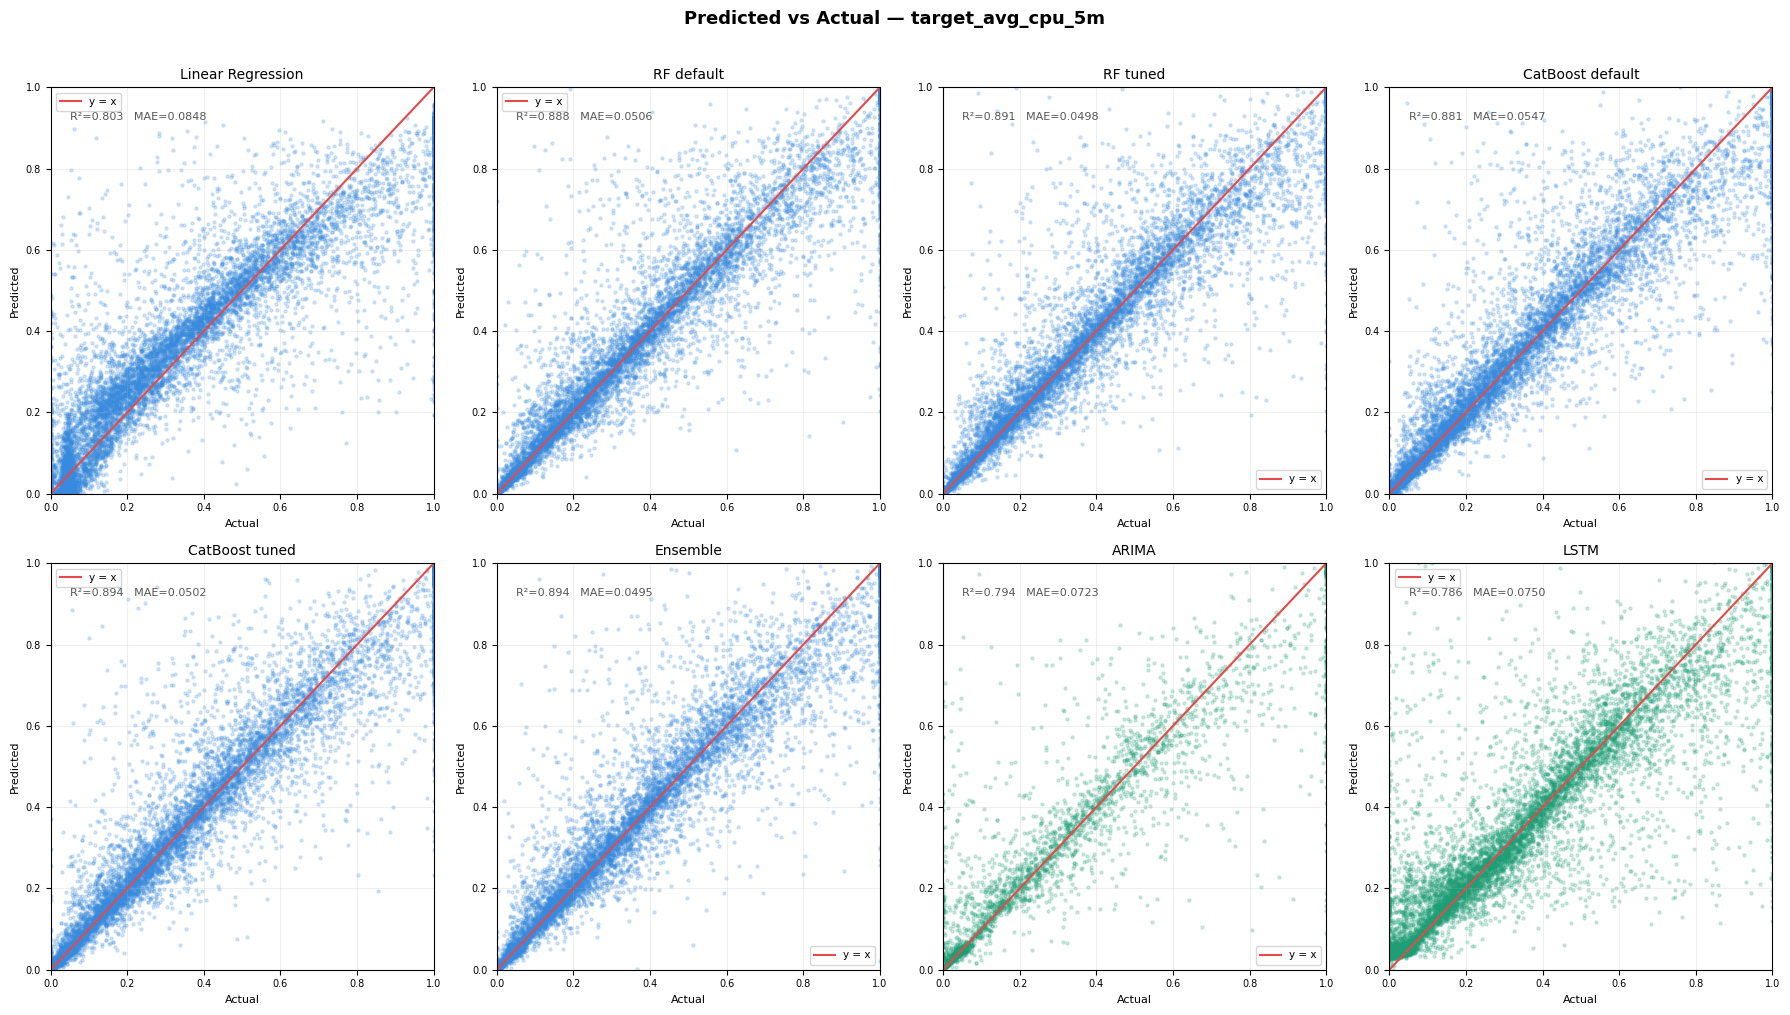

График сохранён: google_predicted_vs_actual_target_avg_cpu_5m.png


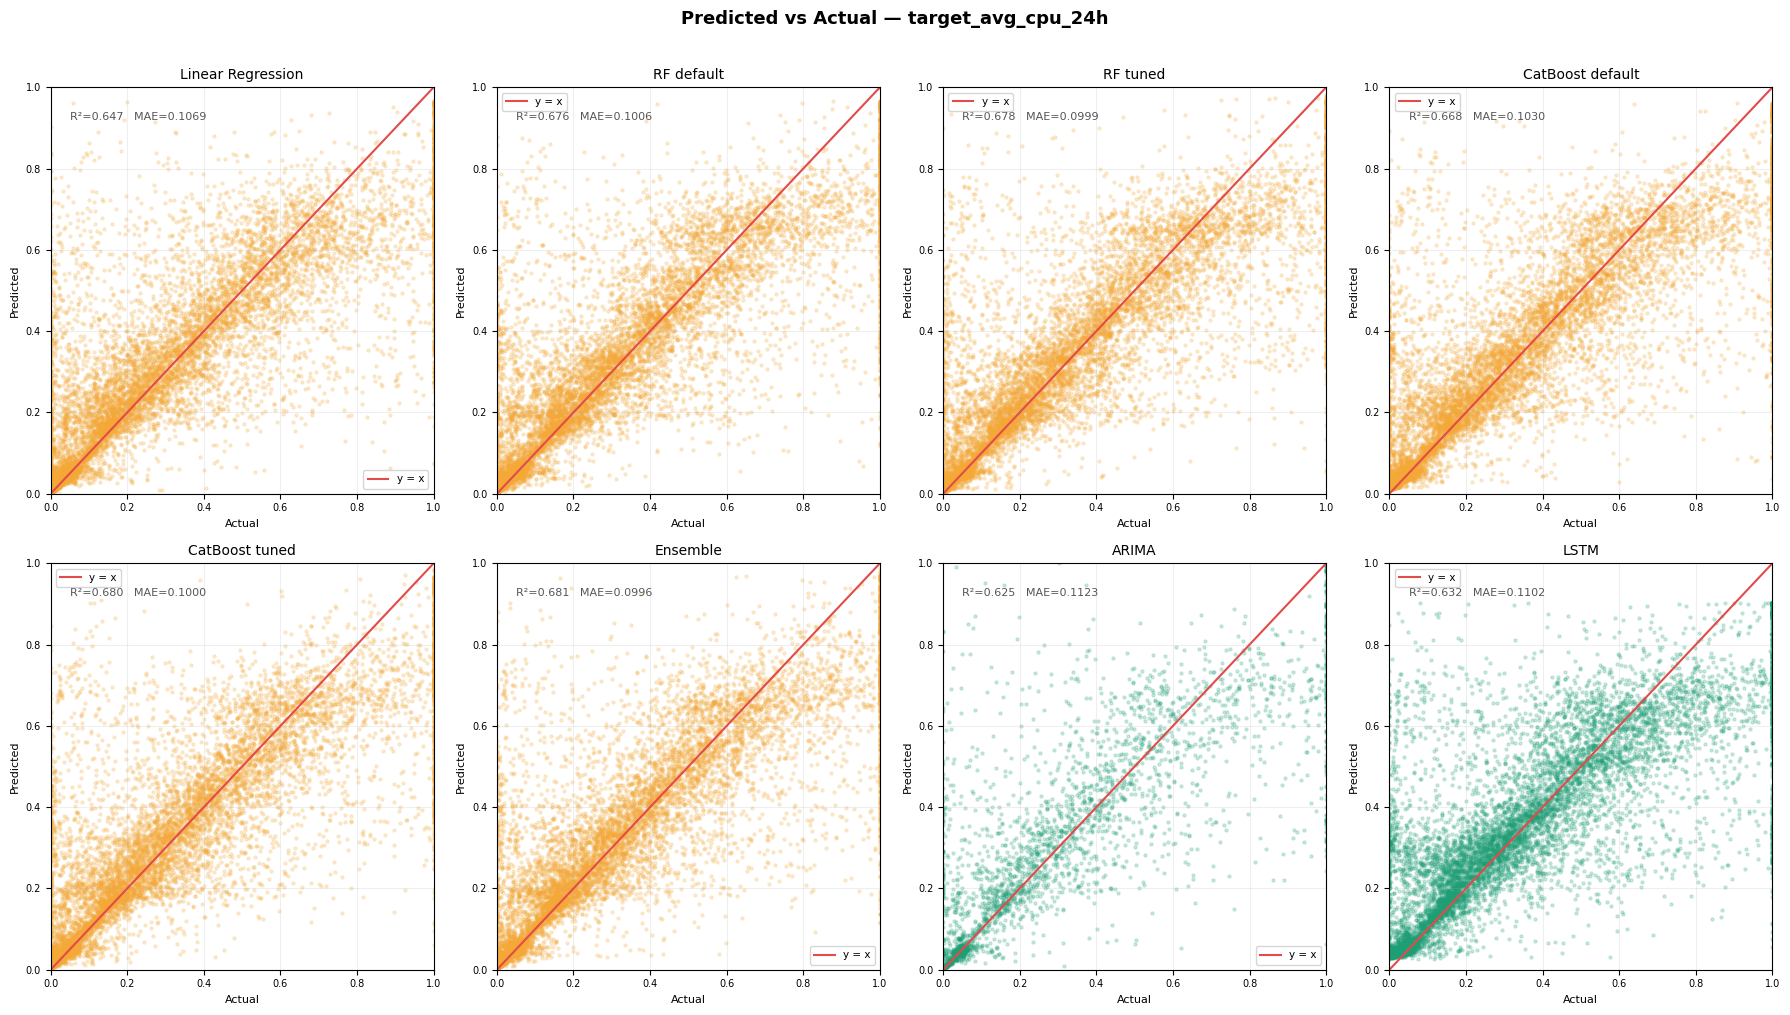

График сохранён: google_predicted_vs_actual_target_avg_cpu_24h.png


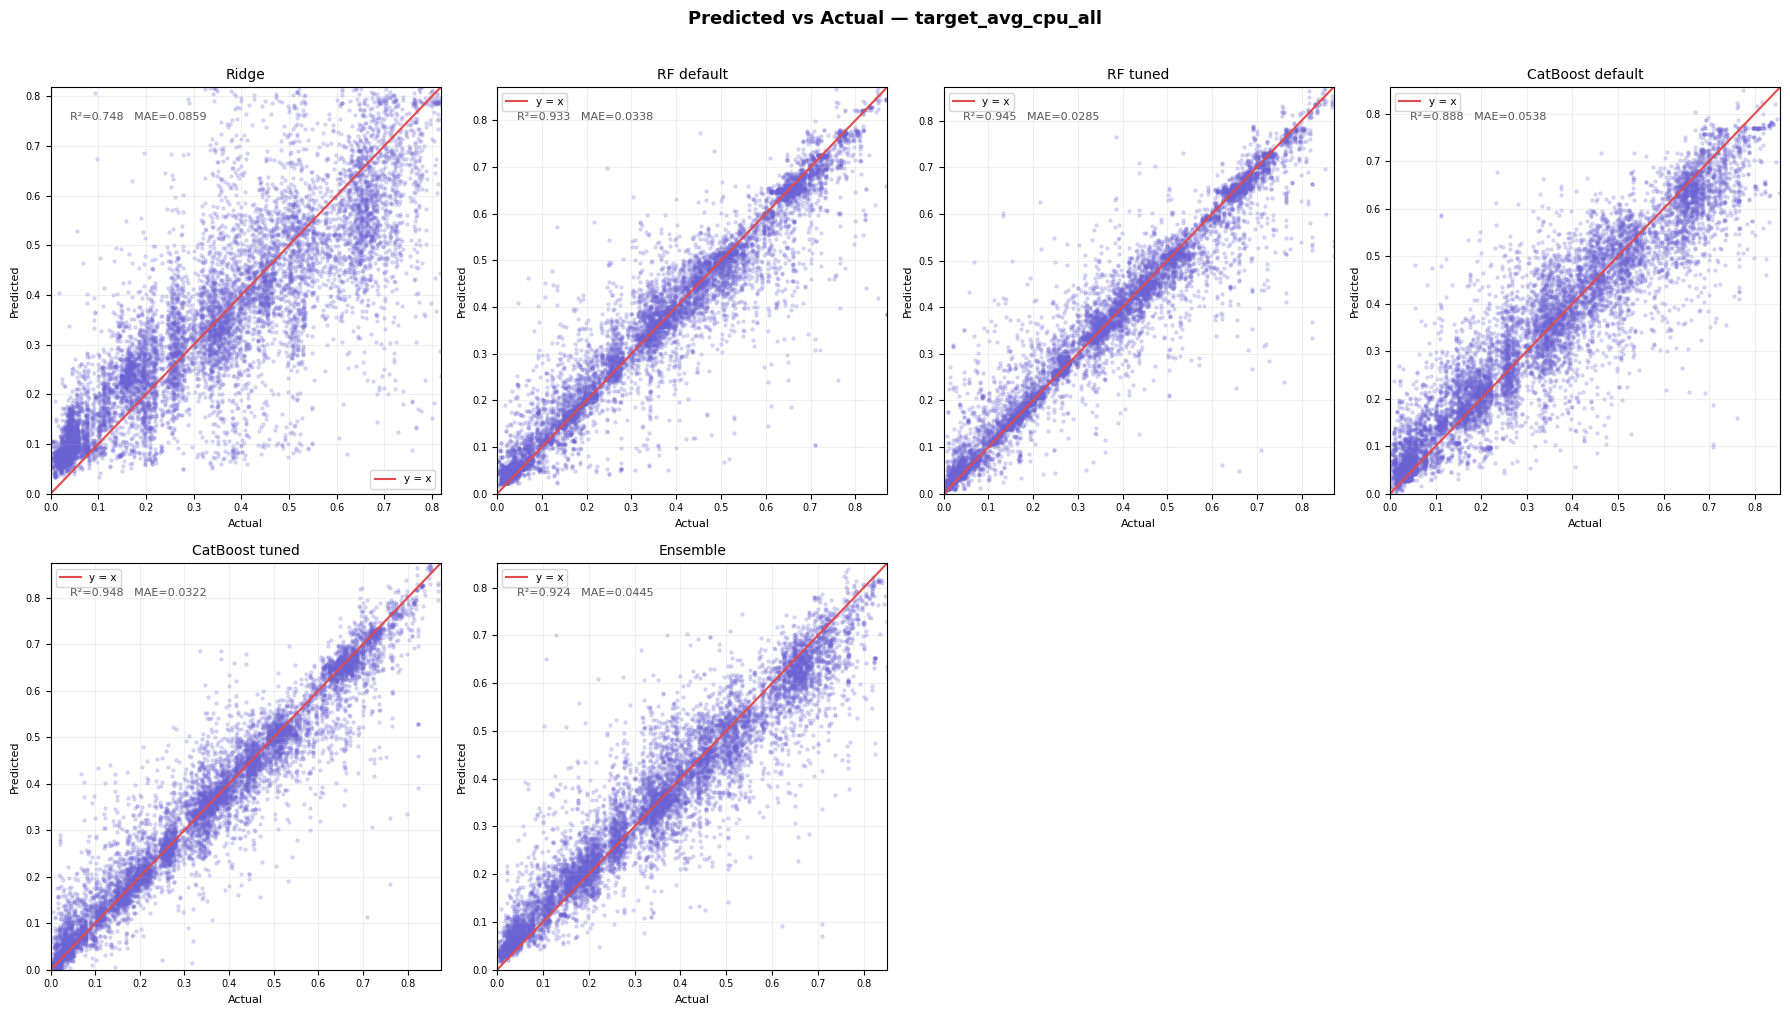

График сохранён: google_predicted_vs_actual_target_avg_cpu_all.png


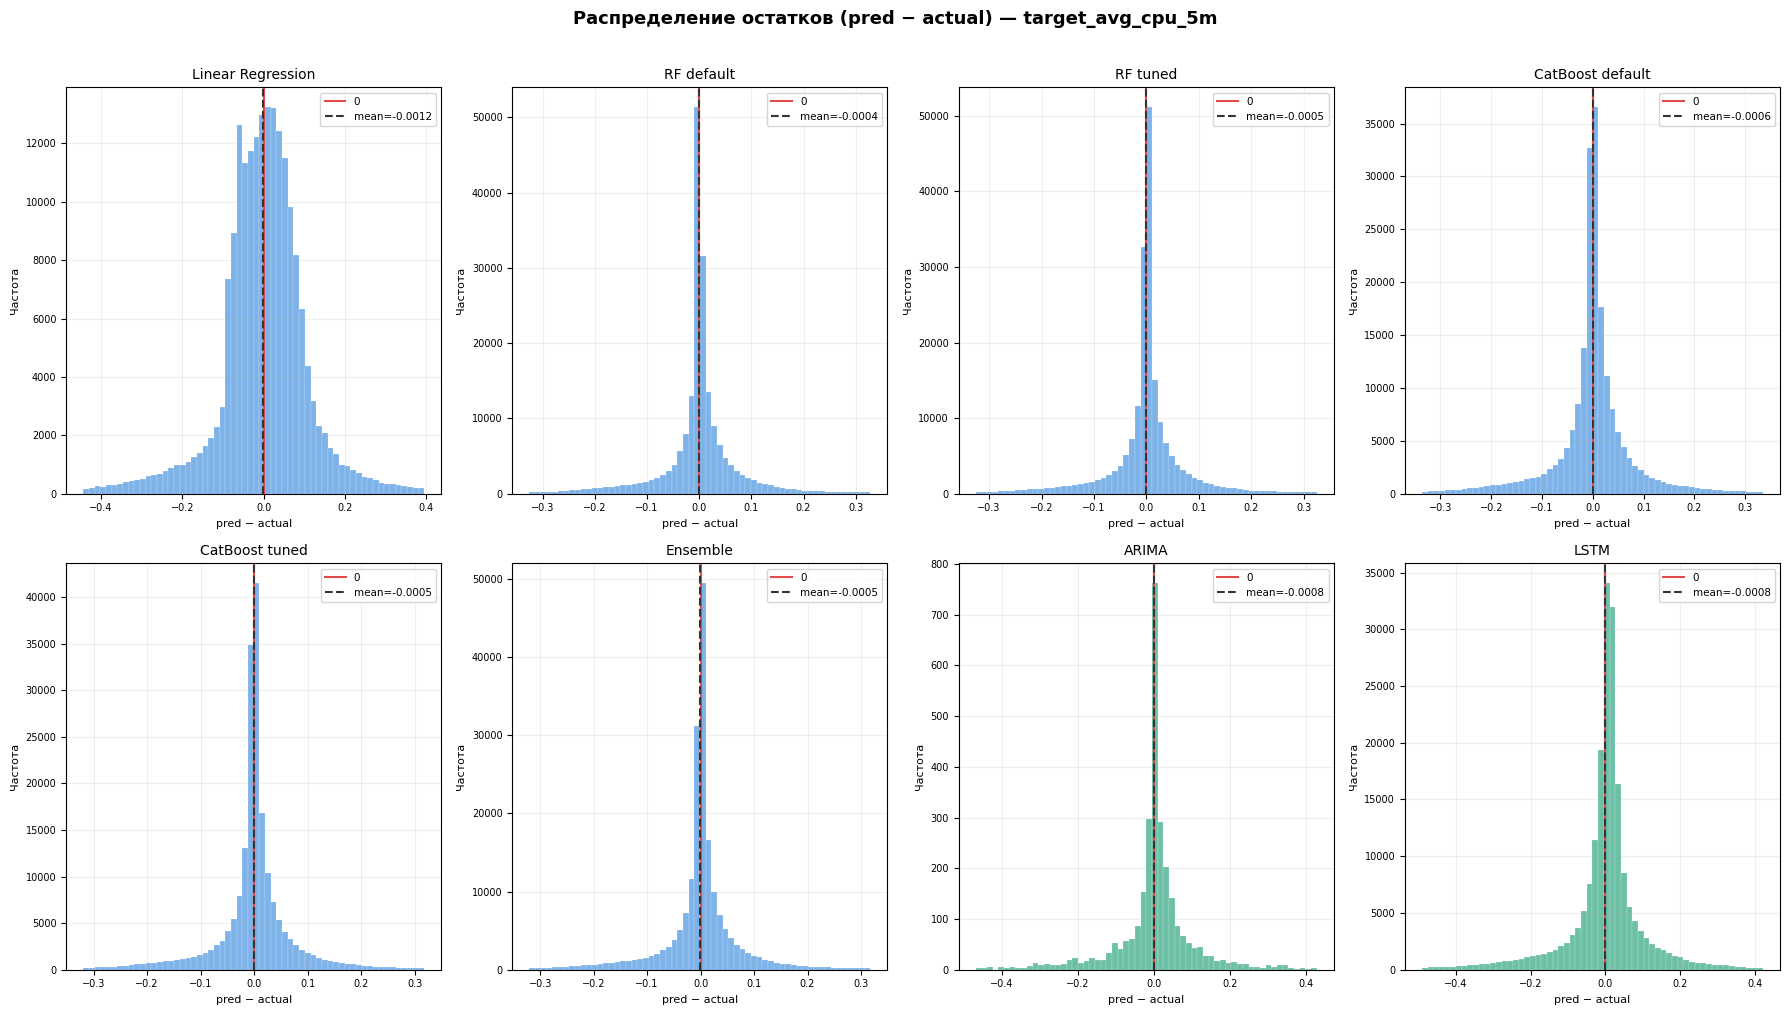

График сохранён: google_residuals_target_avg_cpu_5m.png


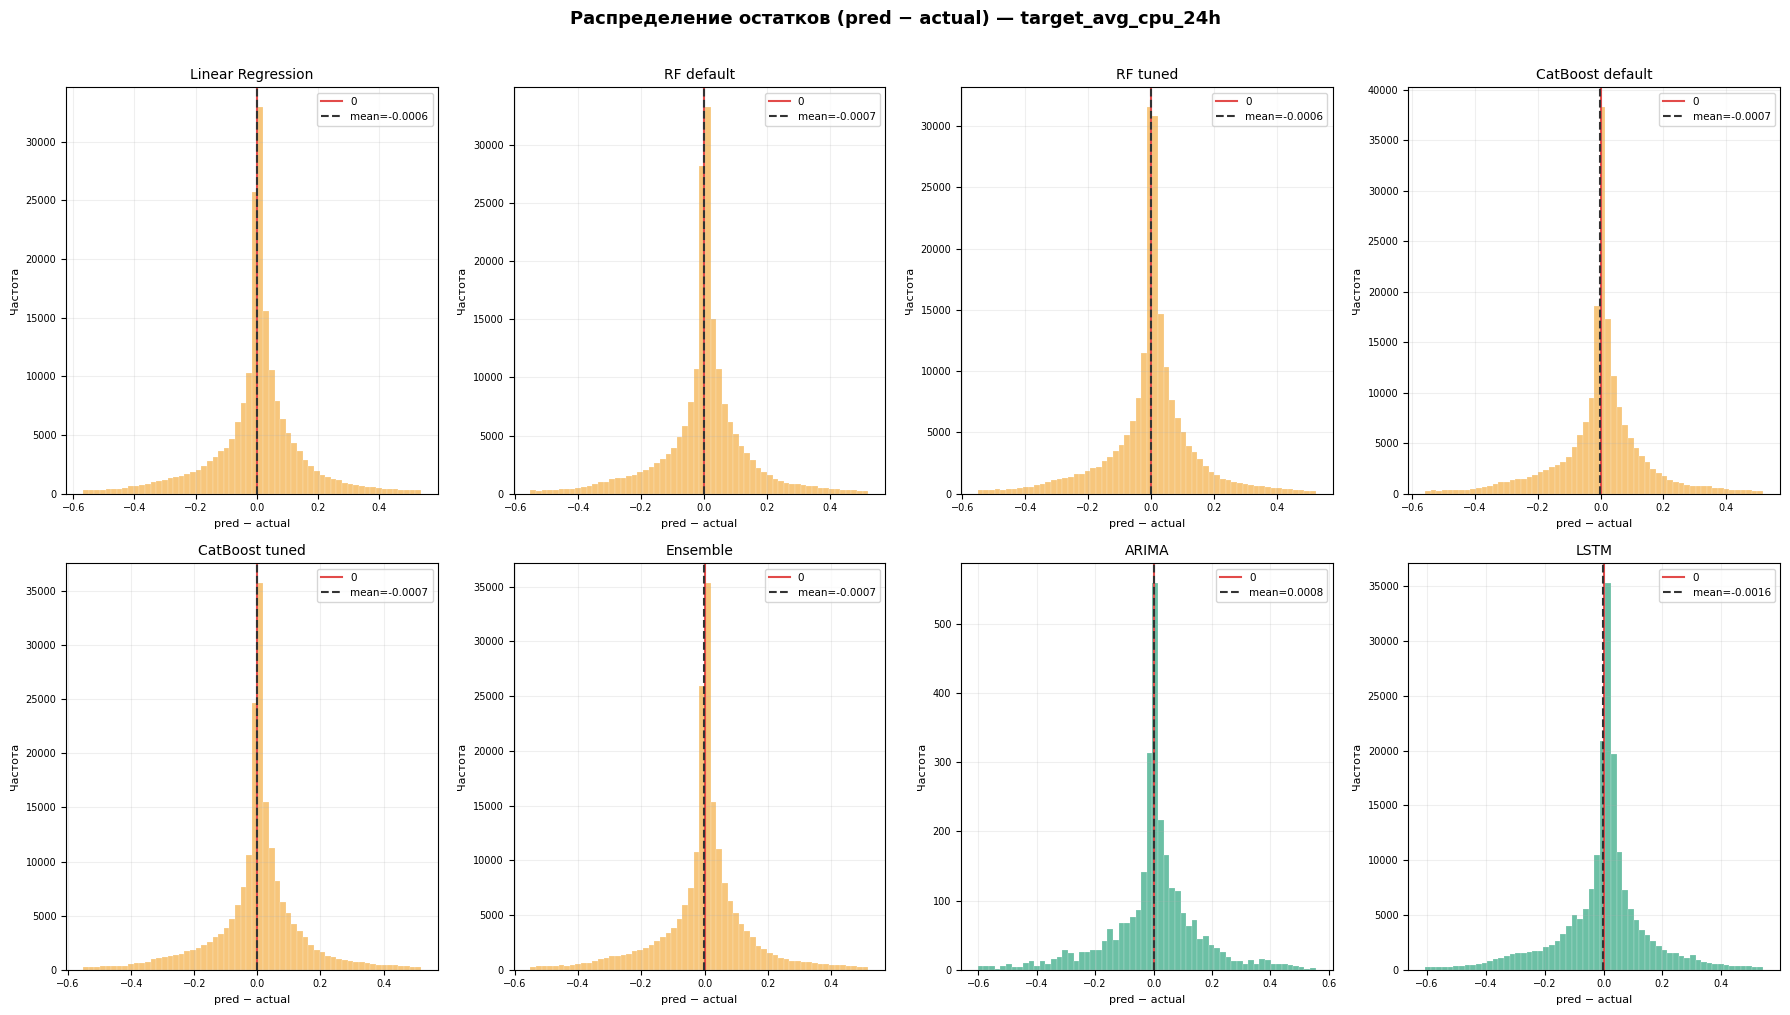

График сохранён: google_residuals_target_avg_cpu_24h.png


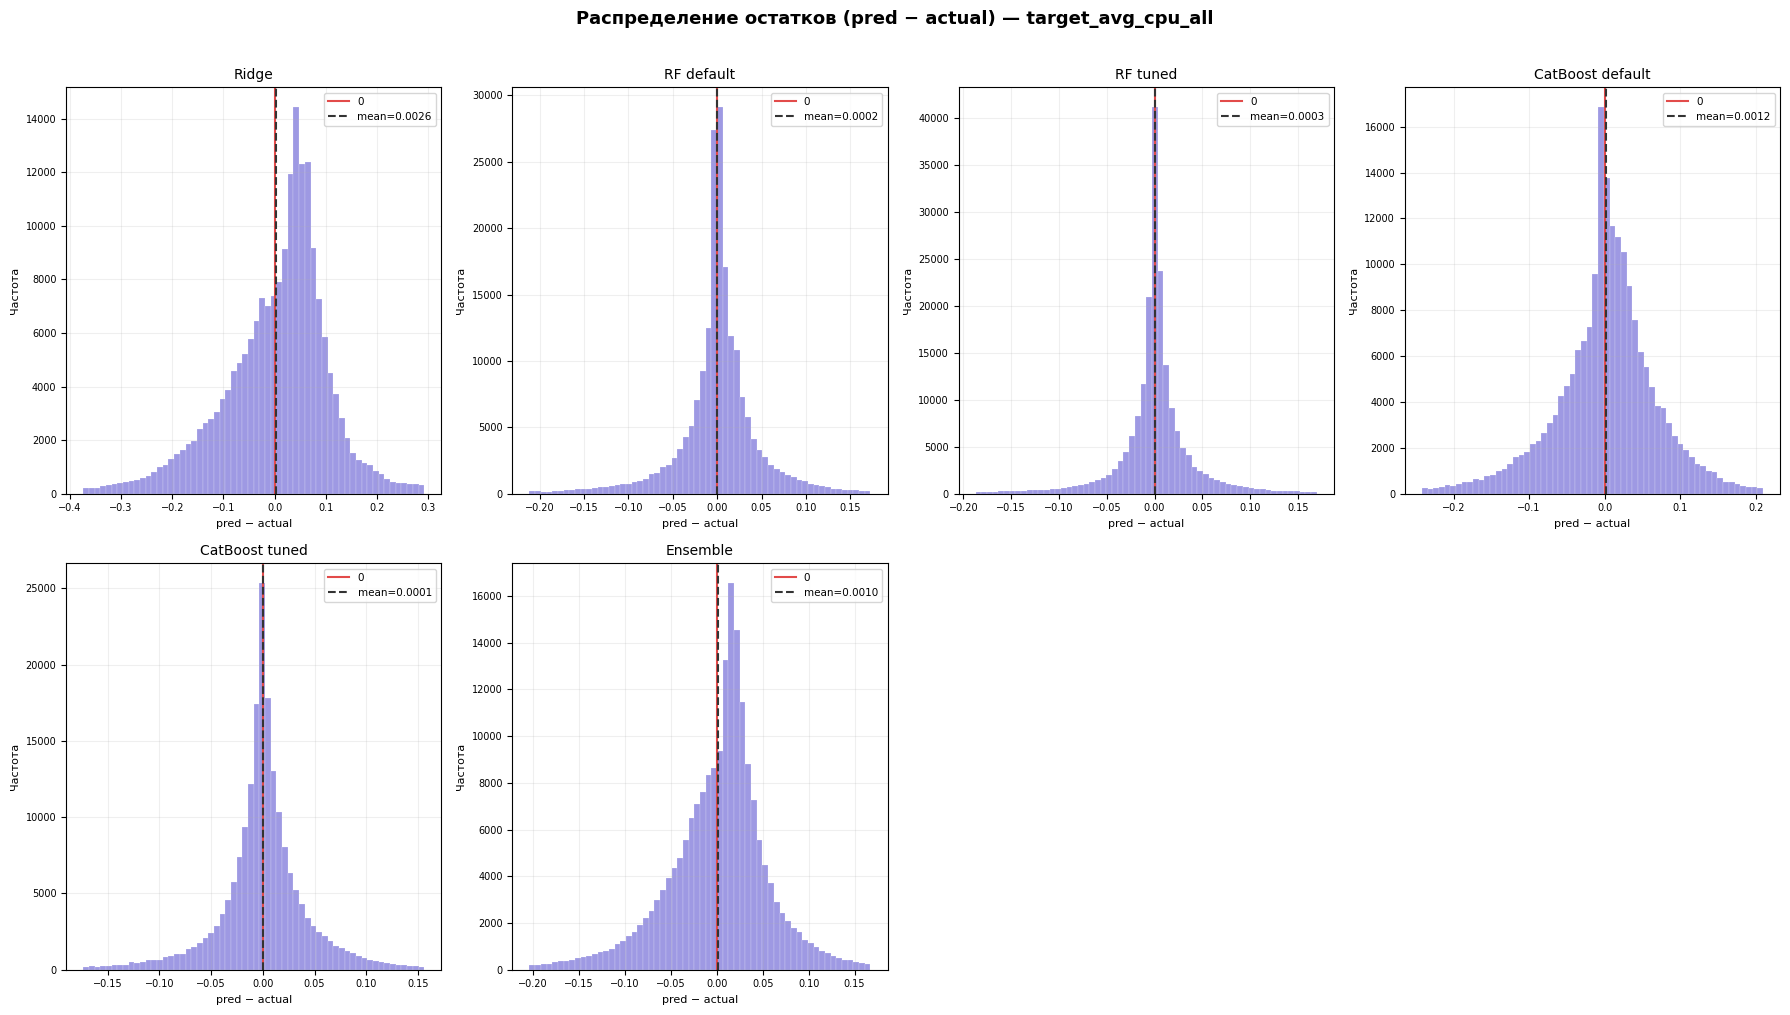

График сохранён: google_residuals_target_avg_cpu_all.png


/tmp/ipykernel_199475/3285830407.py:197: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mae_dec          = df_tmp.groupby('decile').apply(
/tmp/ipykernel_199475/3285830407.py:197: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mae_dec          = df_tmp.groupby('decile').apply(
/tmp/ipykernel_199475/3285830407.py:197: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, an

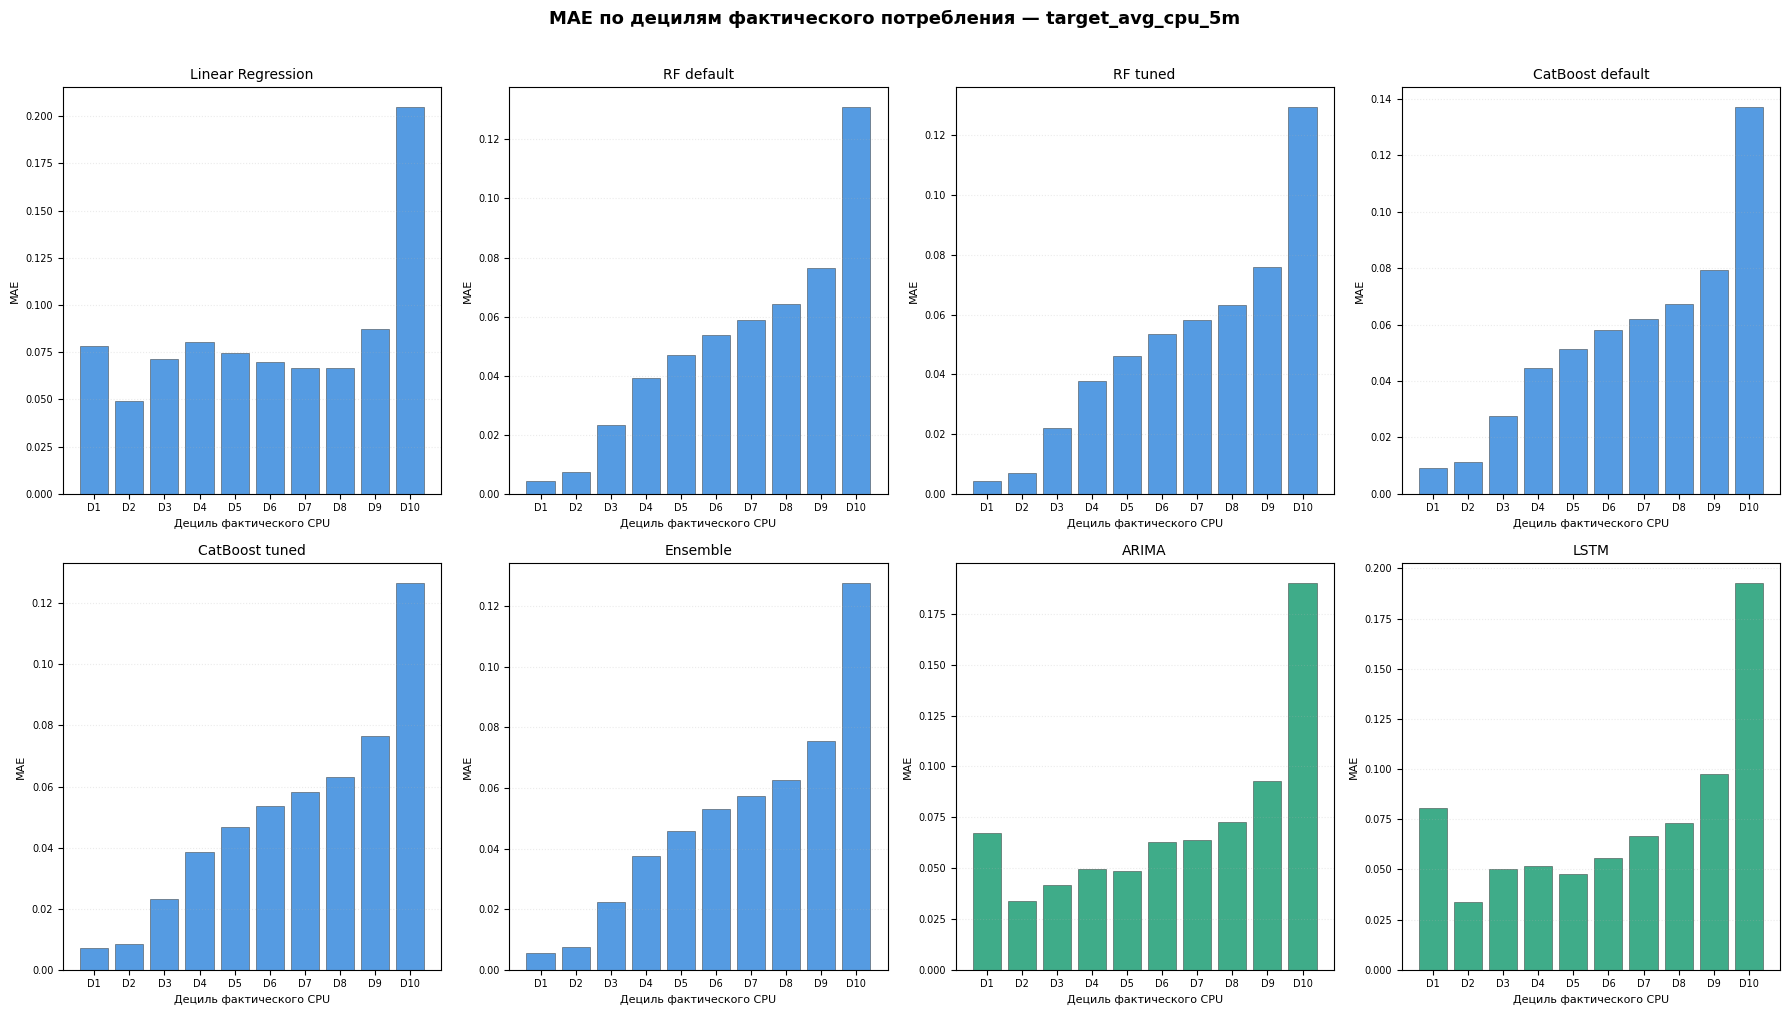

График сохранён: google_mae_by_decile_target_avg_cpu_5m.png


/tmp/ipykernel_199475/3285830407.py:197: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mae_dec          = df_tmp.groupby('decile').apply(
/tmp/ipykernel_199475/3285830407.py:197: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mae_dec          = df_tmp.groupby('decile').apply(
/tmp/ipykernel_199475/3285830407.py:197: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, an

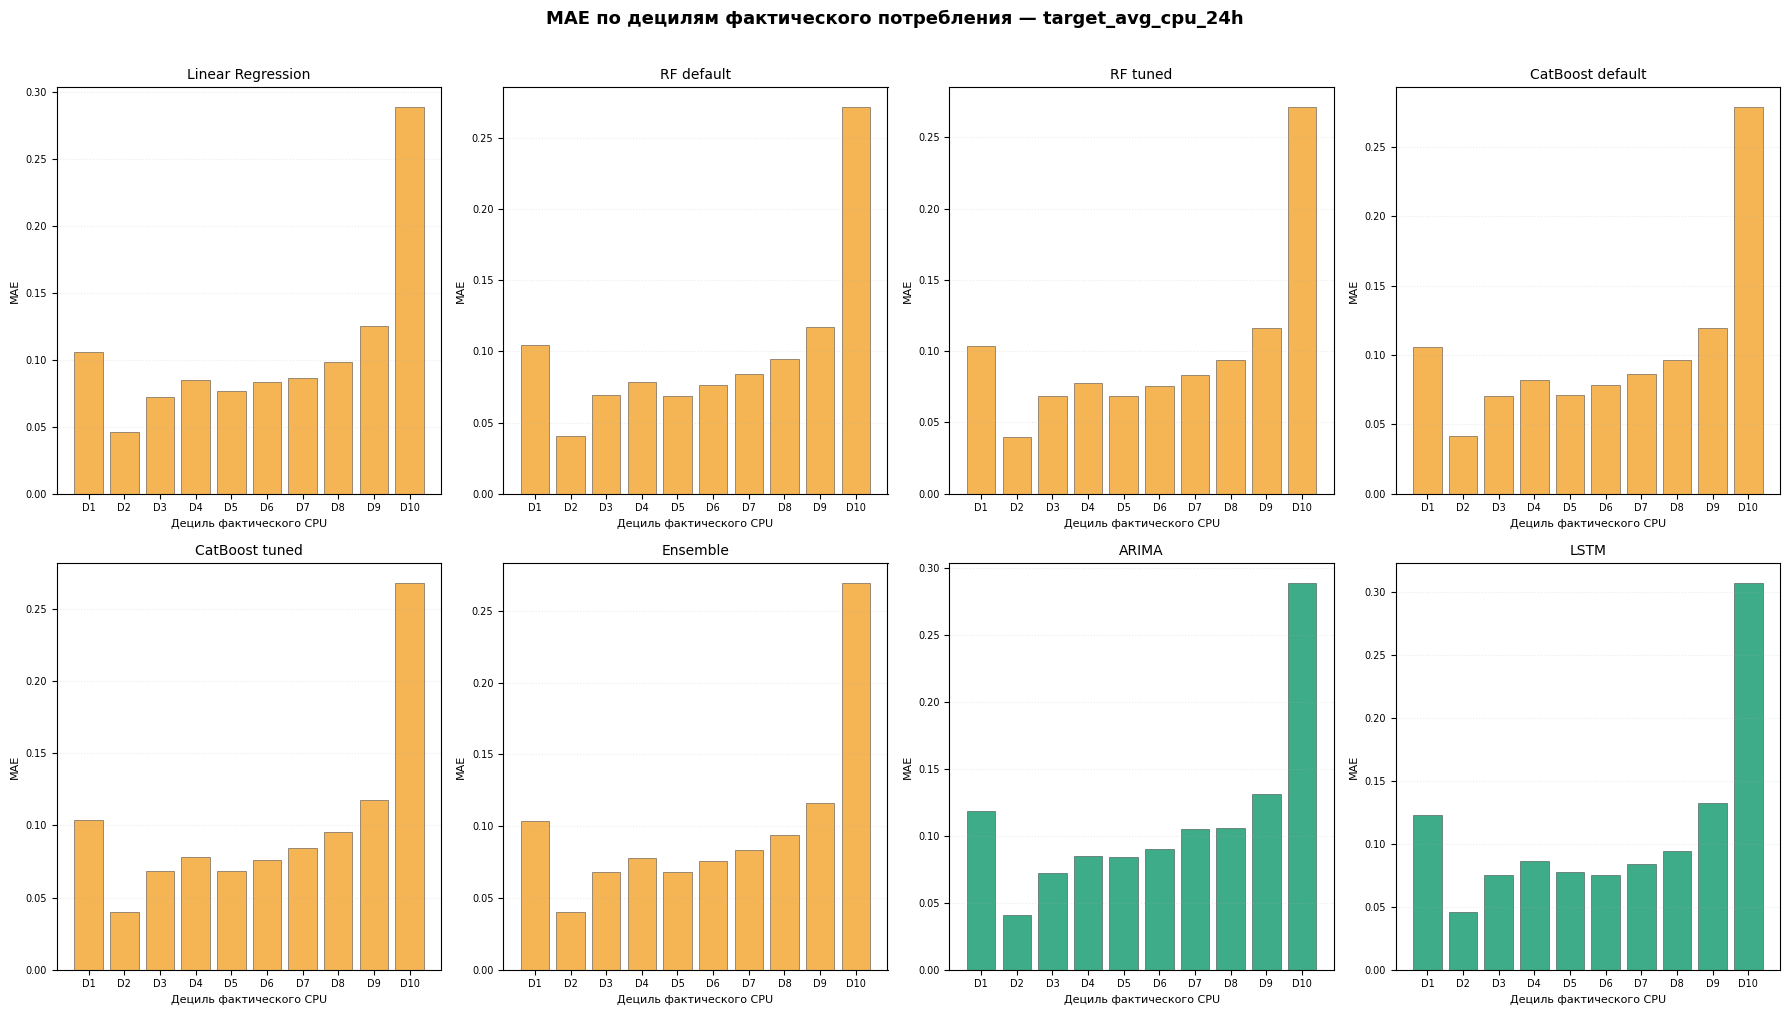

График сохранён: google_mae_by_decile_target_avg_cpu_24h.png


/tmp/ipykernel_199475/3285830407.py:197: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mae_dec          = df_tmp.groupby('decile').apply(
/tmp/ipykernel_199475/3285830407.py:197: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mae_dec          = df_tmp.groupby('decile').apply(
/tmp/ipykernel_199475/3285830407.py:197: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, an

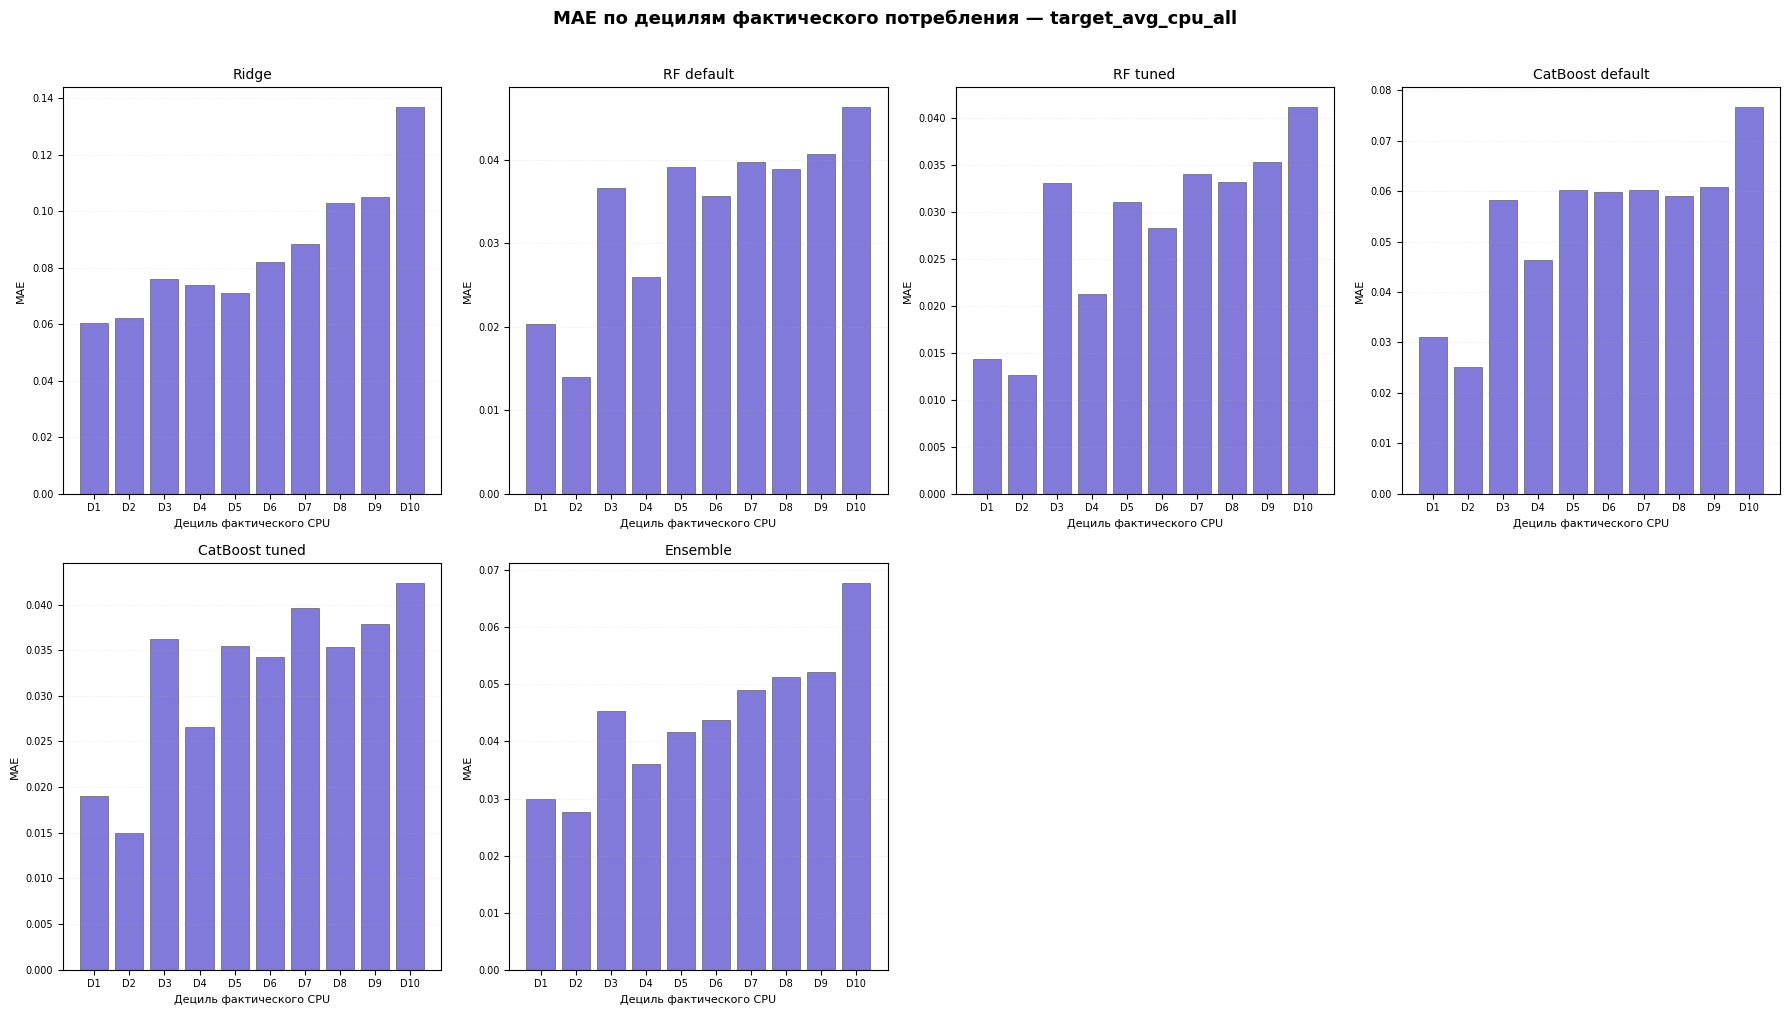

График сохранён: google_mae_by_decile_target_avg_cpu_all.png


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ==============================================================
# ДИАГРАММЫ РАССЕЯНИЯ И ОСТАТКОВ — GOOGLE CLUSTER DATA 2019
# ==============================================================

df_5m       = pd.read_parquet('FE_google/features_result/predictions_5m_models.parquet')
df_24h      = pd.read_parquet('FE_google/features_result/predictions_24h_models.parquet')
df_lifetime = pd.read_parquet('FE_google/features_result/predictions_lifetime_models.parquet')
df_lstm     = pd.read_parquet('FE_google/lstm_data/lstm_test_predictions_full.parquet')
df_arima_3k = pd.read_parquet('FE_google/features_result/predictions_arima_test_sample.parquet')

targets = {
    'target_avg_cpu_5m': {
        'Linear Regression': (df_5m['y_true'],         df_5m['pred_linear_regression']),
        'RF default':        (df_5m['y_true'],         df_5m['pred_random_forest_default']),
        'RF tuned':          (df_5m['y_true'],         df_5m['pred_random_forest_tuned']),
        'CatBoost default':  (df_5m['y_true'],         df_5m['pred_catboost_default']),
        'CatBoost tuned':    (df_5m['y_true'],         df_5m['pred_catboost_tuned']),
        'Ensemble':          (df_5m['y_true'],         df_5m['pred_ensemble']),
        'ARIMA':             (df_arima_3k['true_5m'],  df_arima_3k['pred_arima_5m']),
        'LSTM':              (df_lstm['true_5m'],      df_lstm['pred_lstm_5m']),
    },
    'target_avg_cpu_24h': {
        'Linear Regression': (df_24h['y_true'],        df_24h['pred_linear_regression']),
        'RF default':        (df_24h['y_true'],        df_24h['pred_random_forest_default']),
        'RF tuned':          (df_24h['y_true'],        df_24h['pred_random_forest_tuned']),
        'CatBoost default':  (df_24h['y_true'],        df_24h['pred_catboost_default']),
        'CatBoost tuned':    (df_24h['y_true'],        df_24h['pred_catboost_tuned']),
        'Ensemble':          (df_24h['y_true'],        df_24h['pred_ensemble']),
        'ARIMA':             (df_arima_3k['true_24h'], df_arima_3k['pred_arima_24h']),
        'LSTM':              (df_lstm['true_24h'],     df_lstm['pred_lstm_24h']),
    },
    'target_avg_cpu_all': {
        'Ridge':             (df_lifetime['y_true'],   df_lifetime['pred_ridge']),
        'RF default':        (df_lifetime['y_true'],   df_lifetime['pred_random_forest_default']),
        'RF tuned':          (df_lifetime['y_true'],   df_lifetime['pred_random_forest_tuned']),
        'CatBoost default':  (df_lifetime['y_true'],   df_lifetime['pred_catboost_default']),
        'CatBoost tuned':    (df_lifetime['y_true'],   df_lifetime['pred_catboost_tuned']),
        'Ensemble':          (df_lifetime['y_true'],   df_lifetime['pred_ensemble']),
    },
}

TASK_COLORS = {
    'target_avg_cpu_5m':  '#378ADD',
    'target_avg_cpu_24h': '#F4A836',
    'target_avg_cpu_all': '#6B63D4',
}
TS_MODELS = {'ARIMA', 'LSTM'}

def clean(y, p):
    y, p = np.array(y, dtype=float), np.array(p, dtype=float)
    mask = np.isfinite(y) & np.isfinite(p)
    return y[mask], p[mask]

def r2_score(y, p):
    ss_res = np.sum((y - p) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot > 0 else 0.0


# ==============================================================
# ГРАФИК 1: PREDICTED VS ACTUAL
# ==============================================================

for task, models_dict in targets.items():
    n     = len(models_dict)
    ncols = 4
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
    axes = np.array(axes).flatten()
    fig.suptitle(f'Predicted vs Actual — {task}',
                 fontsize=13, fontweight='bold', y=1.01)

    for i, (name, (y_raw, p_raw)) in enumerate(models_dict.items()):
        ax      = axes[i]
        y, p    = clean(y_raw, p_raw)
        color   = '#1D9E75' if name in TS_MODELS else TASK_COLORS[task]

        if len(y) == 0:
            ax.set_title(f'{name}\n(нет данных)', fontsize=9)
            ax.set_visible(True)
            continue

        vmax = np.percentile(np.concatenate([y, p]), 99)
        vmin = 0

        idx = np.random.choice(len(y), min(10_000, len(y)), replace=False)
        ax.scatter(y[idx], p[idx], alpha=0.2, s=5, color=color)
        ax.plot([vmin, vmax], [vmin, vmax], color='#E24B4A',
                linewidth=1.5, label='y = x')

        mae_val = np.mean(np.abs(y - p))
        r2_val  = r2_score(y, p)

        ax.set_xlim(vmin, vmax)
        ax.set_ylim(vmin, vmax)
        ax.set_title(name, fontsize=10, fontweight='medium')
        ax.set_xlabel('Actual', fontsize=8)
        ax.set_ylabel('Predicted', fontsize=8)
        ax.text(0.05, 0.92, f'R²={r2_val:.3f}   MAE={mae_val:.4f}',
                transform=ax.transAxes, fontsize=8, color='#555')
        ax.legend(fontsize=7.5)
        ax.grid(alpha=0.2)
        ax.tick_params(labelsize=7)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    fname = f'google_predicted_vs_actual_{task}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"График сохранён: {fname}")


# ==============================================================
# ГРАФИК 2: РАСПРЕДЕЛЕНИЕ ОСТАТКОВ
# ==============================================================

for task, models_dict in targets.items():
    n     = len(models_dict)
    ncols = 4
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
    axes = np.array(axes).flatten()
    fig.suptitle(f'Распределение остатков (pred − actual) — {task}',
                 fontsize=13, fontweight='bold', y=1.01)

    for i, (name, (y_raw, p_raw)) in enumerate(models_dict.items()):
        ax        = axes[i]
        y, p      = clean(y_raw, p_raw)
        color     = '#1D9E75' if name in TS_MODELS else TASK_COLORS[task]

        if len(y) == 0:
            ax.set_title(f'{name}\n(нет данных)', fontsize=9)
            continue

        residuals = p - y
        # обрезаем хвосты для читаемого графика
        q1, q99   = np.percentile(residuals, 1), np.percentile(residuals, 99)
        res_clip  = residuals[(residuals >= q1) & (residuals <= q99)]

        ax.hist(res_clip, bins=60, color=color, alpha=0.65,
                edgecolor='white', linewidth=0.2)
        ax.axvline(0,                color='#E24B4A', linewidth=1.5, label='0')
        ax.axvline(residuals.mean(), color='#333',    linewidth=1.5,
                   linestyle='--',   label=f'mean={residuals.mean():.4f}')

        ax.set_title(name, fontsize=10, fontweight='medium')
        ax.set_xlabel('pred − actual', fontsize=8)
        ax.set_ylabel('Частота', fontsize=8)
        ax.legend(fontsize=7.5)
        ax.grid(alpha=0.2)
        ax.tick_params(labelsize=7)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    fname = f'google_residuals_{task}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"График сохранён: {fname}")


# ==============================================================
# ГРАФИК 3: MAE ПО ДЕЦИЛЯМ ФАКТИЧЕСКОГО ПОТРЕБЛЕНИЯ
# ==============================================================

for task, models_dict in targets.items():
    n     = len(models_dict)
    ncols = 4
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
    axes = np.array(axes).flatten()
    fig.suptitle(f'MAE по децилям фактического потребления — {task}',
                 fontsize=13, fontweight='bold', y=1.01)

    for i, (name, (y_raw, p_raw)) in enumerate(models_dict.items()):
        ax    = axes[i]
        y, p  = clean(y_raw, p_raw)
        color = '#1D9E75' if name in TS_MODELS else TASK_COLORS[task]

        if len(y) < 20:
            ax.set_title(f'{name}\n(нет данных)', fontsize=9)
            continue

        df_tmp           = pd.DataFrame({'y': y, 'p': p})
        df_tmp['decile'] = pd.qcut(df_tmp['y'], 10, labels=False, duplicates='drop')
        mae_dec          = df_tmp.groupby('decile').apply(
            lambda g: np.mean(np.abs(g['y'] - g['p']))).reset_index()
        mae_dec.columns  = ['decile', 'mae']

        ax.bar(mae_dec['decile'], mae_dec['mae'],
               color=color, edgecolor='#333', linewidth=0.4, alpha=0.85)
        ax.set_title(name, fontsize=10, fontweight='medium')
        ax.set_xlabel('Дециль фактического CPU', fontsize=8)
        ax.set_ylabel('MAE', fontsize=8)
        ax.set_xticks(range(len(mae_dec)))
        ax.set_xticklabels([f'D{int(d)+1}' for d in mae_dec['decile']], fontsize=7)
        ax.grid(axis='y', alpha=0.25, linestyle=':')
        ax.tick_params(labelsize=7)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    fname = f'google_mae_by_decile_{task}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"График сохранён: {fname}")

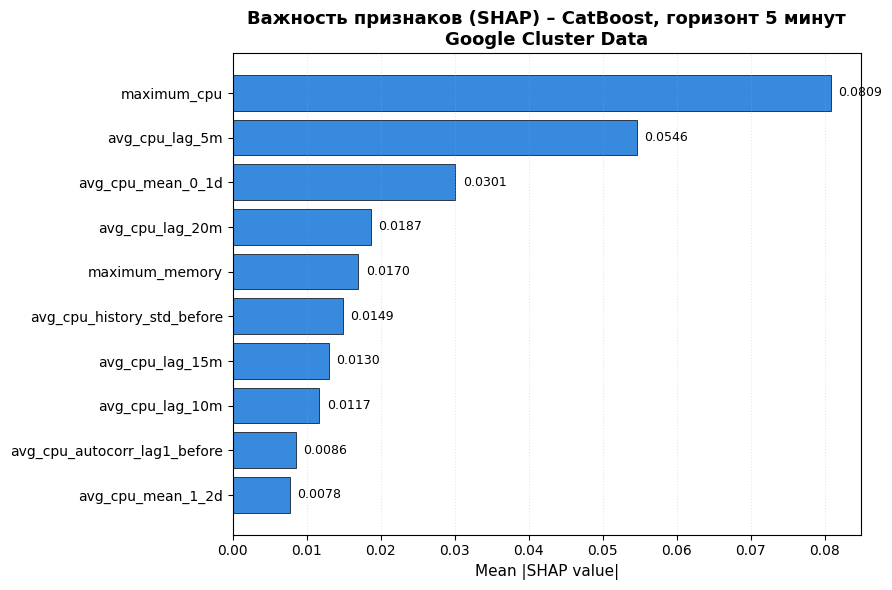

График сохранён: shap_importance_google_5min.png


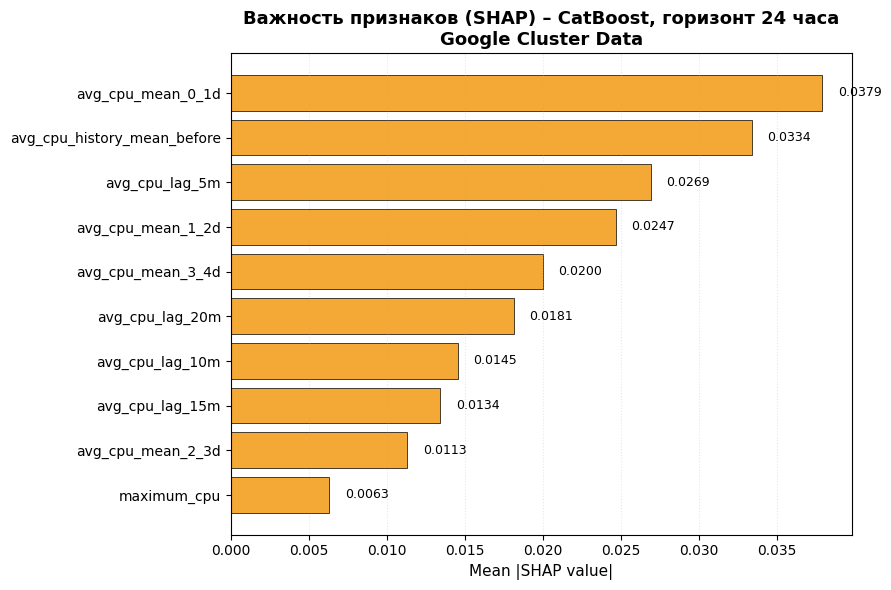

График сохранён: shap_importance_google_24h.png


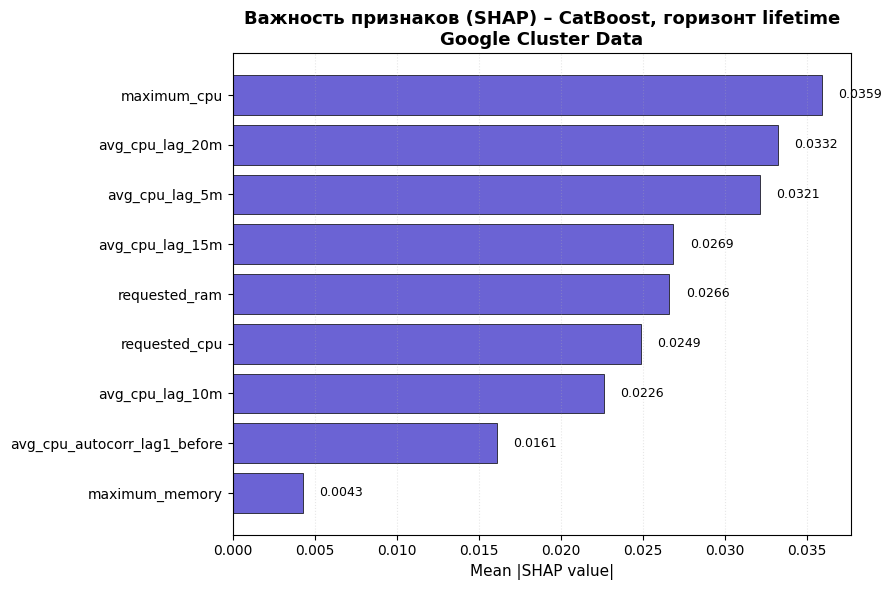

График сохранён: shap_importance_google_lifetime.png


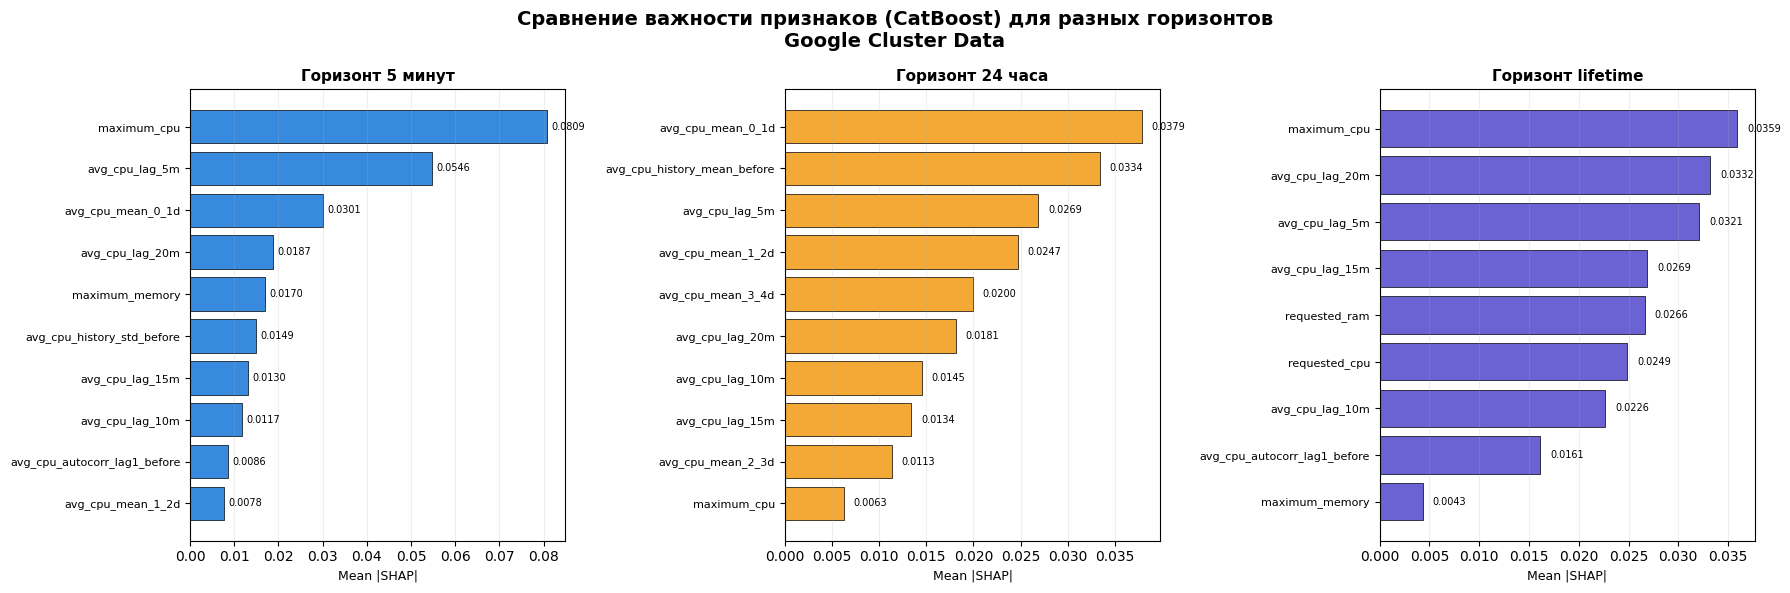

Объединённый график сохранён: shap_importance_all_horizons_google.png


In [9]:
import matplotlib.pyplot as plt
import numpy as np

# ==============================================================
# ДАННЫЕ SHAP IMPORTANCE (CatBoost tuned) для Google Cluster
# ==============================================================

# Горизонт 5 минут
features_5m = [
    "maximum_cpu",
    "avg_cpu_lag_5m",
    "avg_cpu_mean_0_1d",
    "avg_cpu_lag_20m",
    "maximum_memory",
    "avg_cpu_history_std_before",
    "avg_cpu_lag_15m",
    "avg_cpu_lag_10m",
    "avg_cpu_autocorr_lag1_before",
    "avg_cpu_mean_1_2d"
]
shap_5m = [0.080865, 0.054637, 0.030096, 0.018702, 0.016998,
           0.014932, 0.013033, 0.011739, 0.008560, 0.007774]

# Горизонт 24 часа
features_24h = [
    "avg_cpu_mean_0_1d",
    "avg_cpu_history_mean_before",
    "avg_cpu_lag_5m",
    "avg_cpu_mean_1_2d",
    "avg_cpu_mean_3_4d",
    "avg_cpu_lag_20m",
    "avg_cpu_lag_10m",
    "avg_cpu_lag_15m",
    "avg_cpu_mean_2_3d",
    "maximum_cpu"
]
shap_24h = [0.037900, 0.033378, 0.026896, 0.024671, 0.019975,
            0.018132, 0.014541, 0.013426, 0.011309, 0.006300]

# Горизонт lifetime
features_life = [
    "maximum_cpu",
    "avg_cpu_lag_20m",
    "avg_cpu_lag_5m",
    "avg_cpu_lag_15m",
    "requested_ram",
    "requested_cpu",
    "avg_cpu_lag_10m",
    "avg_cpu_autocorr_lag1_before",
    "maximum_memory"
]
shap_life = [0.035904, 0.033223, 0.032132, 0.026869, 0.026633,
             0.024878, 0.022642, 0.016116, 0.004302]

# ==============================================================
# ФУНКЦИЯ ДЛЯ ПОСТРОЕНИЯ ГОРИЗОНТАЛЬНОГО BARPLOT
# ==============================================================

def plot_feature_importance(features, shap_values, title, filename, color='#2E86AB'):
    """
    Строит горизонтальную столбчатую диаграмму важности признаков.
    """
    # Сортируем по убыванию SHAP (на случай, если данные уже не отсортированы)
    pairs = sorted(zip(shap_values, features), reverse=True)
    shap_sorted, features_sorted = zip(*pairs)
    
    plt.figure(figsize=(9, 6))
    y_pos = np.arange(len(features_sorted))
    bars = plt.barh(y_pos, shap_sorted, color=color, edgecolor='black', linewidth=0.5)
    
    # Подписываем значения справа от каждого бара
    for i, (bar, val) in enumerate(zip(bars, shap_sorted)):
        plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)
    
    plt.yticks(y_pos, features_sorted, fontsize=10)
    plt.xlabel('Mean |SHAP value|', fontsize=11)
    plt.title(title, fontsize=13, fontweight='bold')
    plt.gca().invert_yaxis()  # чтобы самый важный был сверху
    plt.grid(axis='x', alpha=0.3, linestyle=':')
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"График сохранён: {filename}")

# ==============================================================
# ПОСТРОЕНИЕ ТРЁХ ГРАФИКОВ
# ==============================================================

plot_feature_importance(
    features_5m, shap_5m,
    title="Важность признаков (SHAP) – CatBoost, горизонт 5 минут\nGoogle Cluster Data",
    filename="shap_importance_google_5min.png",
    color='#378ADD'
)

plot_feature_importance(
    features_24h, shap_24h,
    title="Важность признаков (SHAP) – CatBoost, горизонт 24 часа\nGoogle Cluster Data",
    filename="shap_importance_google_24h.png",
    color='#F4A836'
)

plot_feature_importance(
    features_life, shap_life,
    title="Важность признаков (SHAP) – CatBoost, горизонт lifetime\nGoogle Cluster Data",
    filename="shap_importance_google_lifetime.png",
    color='#6B63D4'
)

# ==============================================================
# (Опционально) ОБЪЕДИНЁННЫЙ ГРАФИК ВСЕХ ТРЁХ ГОРИЗОНТОВ
# ==============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ['#378ADD', '#F4A836', '#6B63D4']
data = [(features_5m, shap_5m, "5 минут"),
        (features_24h, shap_24h, "24 часа"),
        (features_life, shap_life, "lifetime")]

for ax, (feat, val, horizon), col in zip(axes, data, colors):
    pairs = sorted(zip(val, feat), reverse=True)
    sv, fv = zip(*pairs)
    ypos = np.arange(len(fv))
    bars = ax.barh(ypos, sv, color=col, edgecolor='black', linewidth=0.5)
    for bar, v in zip(bars, sv):
        ax.text(v + 0.001, bar.get_y() + bar.get_height()/2,
                f'{v:.4f}', va='center', fontsize=7)
    ax.set_yticks(ypos)
    ax.set_yticklabels(fv, fontsize=8)
    ax.set_title(f'Горизонт {horizon}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Mean |SHAP|', fontsize=9)
    ax.grid(axis='x', alpha=0.2)
    ax.invert_yaxis()

plt.suptitle('Сравнение важности признаков (CatBoost) для разных горизонтов\nGoogle Cluster Data',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("shap_importance_all_horizons_google.png", dpi=150, bbox_inches='tight')
plt.show()
print("Объединённый график сохранён: shap_importance_all_horizons_google.png")